# Deep model implementation
---
In this notebook we will start by developing the deep learning models, our approach is as follow:
1. **Char-CNN** (baseline) - Multiscale convolution architecture
2. **CNN +BiLSTM** a hypbrid CNN-RNN for char sequence modeling
3. **FastText + CNN** - a subword n-gram embedding offers a lightweight approach suitable for our CPU only constrain
4.  **Hybrid Feature Fusion** Deep features based on Random forest feature importance analysis + statistical features (length, entropy, special char ratio) → Fusion



## Outcomes
---
- Performance comparison across models (accuracy, precision, recall, F1)
- Model size vs. performance tradeoff analysis
- False positive/negative analysis


# What is added in this version ?
---
Organization - checking and confusion matirces



# Imports and configurations

In [ ]:
!pip install -U torch==2.3.0+cpu torchtext==0.18.0 --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
import pickle
# deep model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader , WeightedRandomSampler

# fasttext
import torchtext.vocab as vocab
import torchtext.vocab as vocab_module
from torchtext.data.utils import get_tokenizer
#evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)



from tqdm import tqdm
import math
import re
import hashlib
import time

# configurations
np.random.seed(42)
torch.manual_seed(42)

# training
batch_size = 256
MAX_LEN = 200

# Loading the training dataset & Intial setting
For the preprocessing refer to the data folder

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df['Label'].value_counts()

,count
Label,
0,52480
1,38363


In [ ]:
df['URL_len']= df['URL'].apply(len)

In [ ]:
df['URL_len'].describe()

,URL_len
count,90843.000000
mean,78.309171
std,127.302557
min,11.000000
25%,38.000000
50%,56.000000
75%,87.000000
max,25515.000000


25515 seems to be an outlier

In [ ]:
df[df['URL_len'] > 6000]

,URL,Label,URL_len
48426,https://authjgxszcloxpnassocl.web.app/hashsso/...,1,25515


it is an outlier we need to check the distribution

In [ ]:
df[df['URL_len'] > 2000]

,URL,Label,URL_len
5297,https://nh-dpu.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,2165
14208,https://vbp.pages.dev/%5C%5C%5Chttps:%5C/%5C/6...,1,2564
31530,https://b4e921f0.sso-mailsrvr-4344e5teed.pages...,1,5795
35342,https://bg3.pages.dev/%5C%5C%5Chttps:%5C/%5C/6...,1,2165
35954,http://nh-dpu.pages.dev/%5C%5C%5Chttps:%5C/%5C...,1,2164
38308,http://yandex.ru/clck/jsredir?from=yandex.ru%3...,1,3654
45012,https://vb-ezk.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,3441
48426,https://authjgxszcloxpnassocl.web.app/hashsso/...,1,25515
61112,http://cbv.pages.dev/%5C%5C%5Chttps:%5C/%5C/6....,1,2167
61561,https://vb-ezk.pages.dev/%5C%5C%5Chttps:%5C/%5...,1,2165


above 2000 here is also an outlier but notice the majority of very long URL are Labeled 1 they are spam this is not a data erorr it is a real value and this shows that the URL length is an improtant feature that will be useful in the hybrid deep feature fusion model.

In [ ]:
df[df['URL_len'] > 1000]['Label'].value_counts()

,count
Label,
0,156
1,17


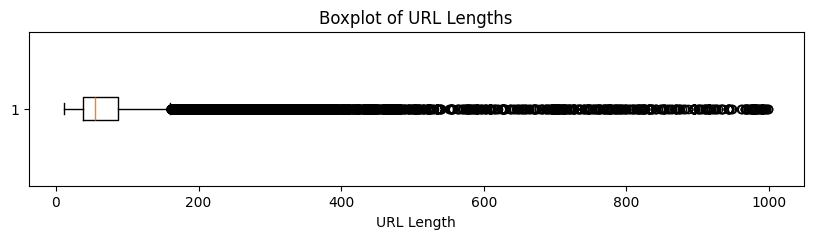

In [ ]:
plt.figure(figsize=(10, 2))


data = df.loc[df['URL_len'] < 1000, 'URL_len']

plt.boxplot(data, vert=False)
plt.xlabel("URL Length")
plt.title("Boxplot of URL Lengths")
plt.show()

Box plot shows alot of outliers are above 200 in URL length and median is nearly at 50

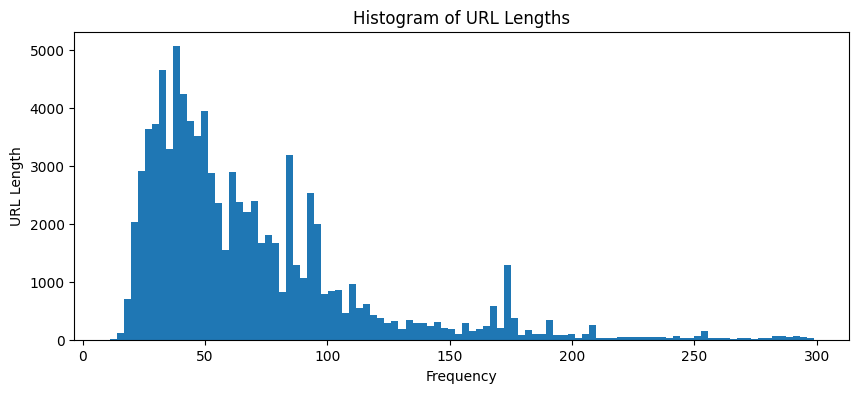

In [ ]:
plt.figure(figsize=(10, 4))

data = df.loc[df['URL_len'] < 300, 'URL_len']

plt.hist(data, bins=100)
plt.ylabel("URL Length")
plt.xlabel("Frequency")
plt.title("Histogram of URL Lengths")

plt.show()

even after trimming extreme values the dataset is heavily right skewed
- For CNN we need fixed input size so we need to truncate to a max length and pad short URL since our data set has a median around 50 and alot of extreme value so a treshold of 200 would be suitable

In [ ]:
train_df = df
val_df = pd.read_csv("val.csv")

In [ ]:
class_counts = train_df['Label'].value_counts()

# Character Vocabulary Builder

In [ ]:
class CharVocab:
  """ Building the char vocabulary from the URL dataset"""

# class constructior with default vocab size of 128 and minimum frequency of 5
  def __init__(self,max_vocab_size = 128 , min_freq =5):
    self.max_vocab_size = max_vocab_size # we should set a max_voacb size to avoid exploded dictionary
    self.min_freq = min_freq # the minimum frequency below which the word is considered too infrequent to include
    self.char2idx = {} # the dictionalry maping characters to index
    self.idx2char = {} # the oposite
    self.pad_idx = 0 # the padding index is 0
    self.unkown_idx=1 # the unkown character index is 1

  def build(self, texts):
    char_counts = Counter()
    for text in texts:
      char_counts.update(text)

    chars = [ch for ch, cnt in char_counts.items() if cnt >= self.min_freq] # only keep chars satisfying frequency treshold
    chars = sorted(chars)[:self.max_vocab_size] # after sorting only keep the max vocab size allowed

    self.char2idx = { '<PAD>': 0 , '<UNK>' : 1}
    self.idx2char = {0: '<PAD>', 1:'<UNK>'}

    for ch in chars:
      idx = len(self.char2idx)
      self.char2idx[ch] = idx # map index to char
      self.idx2char[idx] = ch # map char ot index

    print(f"Vocabulary size: { len(self.char2idx)}")
    return self

# function to encode text characters to their word implementation
  def encode(self , text , max_len =None , pad_to_max = False):
    # get the indices of the given text characters to encode
    indices = [self.char2idx.get(ch,self.unkown_idx) for ch in text]
    if max_len and pad_to_max:
      if len(indices) > max_len:
        indices = indices[:max_len] # trim the extra
      elif len(indices) < max_len:
        indices = indices +[self.pad_idx] * (max_len - len(indices))# pad if shorter
    return indices

  # function to decode
  def decode (self, indices):
    return ''.join([self.idx2char.get(i,'<UNK>') for i in indices])

Build the vocab

In [ ]:
vocab = CharVocab(max_vocab_size= 100 , min_freq =3)
vocab.build(train_df['URL'].values)

Vocabulary size: 92


The vocab size actually is less than 100 so nothing is trimmed

In [ ]:
print(f"fixed max length: { MAX_LEN}")

fixed max length: 200


# creating pytorch dataset

In [ ]:
class URLDataset(Dataset):
  """ Pytorch Dataset for URL classification"""

  def __init__ (self, df, vocab, max_len=200 , augment =False):# the class constractor taking dataset , vocab and max_length , also augment
    self.urls = df['URL'].values
    self.labels = df['Label'].values
    self.vocab = vocab
    self.max_len = max_len
    self.augment = augment
 # overwriting the Dataset Class len function
  def __len__(self):
    return len(self.urls)
  # overwriting the get item function
  def __getitem__(self,idx):
    url = self.urls[idx] # get url by index from the urls dictionary
    label = self.labels[idx]  # get label by index from the label dictionary
    encoded = self.vocab.encode(url, self.max_len, pad_to_max =True)#encode the url

    if self.augment and np.random.random() < 0.1: # augmentation happend occationally with probability 10%
      mask = np.random.random(len(encoded))<0.05 # lonly 5% of tokens are set to true in the mask
      for i in range(len(encoded)):
        if mask[i] and encoded[i]>1: # the index is selected by mask and encoded value is greater than one to avoid modifying pad 0 or unknown 1
          encoded[i] = self.vocab.unkown_idx  # replace the selected to token with unknown_idx 1 to make the model more robust

    return torch.tensor(encoded,dtype= torch.long), torch.tensor(label, dtype = torch.float) # convert lables to float tensor first tensor of encoded long as characters are encoded as whole numbers and might be larger than integer url and second is encoded float lable 0.0 or 1.0 as precidtionis will be between 0 and 1 so that binary cross enntropy functin apply


In [ ]:

# Create datasets
train_dataset = URLDataset(train_df, vocab, MAX_LEN, augment=True)
val_dataset = URLDataset(val_df, vocab, MAX_LEN, augment=False)

# Handle class imbalance with weighted sampler
class_weights = {0: 1.0/class_counts[0], 1: 1.0/class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['Label'].values]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Create dataloaders
#batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0 )
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers= 0)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 355, Val batches: 77


training set size = 90000 / 256 ~ 351 with  padding 355 which is a rational increase

# Char CNN

In [ ]:
class CharCNN(nn.Module):
  """ Character-level CNN with multi-scale kernels"""
  # create charCNN constructor
  def __init__(self , vocab_size, embed_dim = 64, num_filters=128, kernel_sizes=[3,5,7], dropout=0.3):
  # since we have a batch size of 256 URL each is padded or truncated to length 200 token each token is represented by 64 embedding vector the resulting tensor is [256,200,64]
    super(CharCNN, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim , padding_idx = 0) # embedding layer

    # three 1D convlution layers each look at different subset using kernels  of 3 , 5 , 7 to capture diffent url words
    self.convs = nn.ModuleList([
        nn.Conv1d(embed_dim , num_filters, k, padding = k//2)
        for k in kernel_sizes
    ])

    # batch normalization for each of the three kernel each has 128 filter /feature
    self.batch_norms = nn.ModuleList([
        nn.BatchNorm1d(num_filters) for _ in kernel_sizes
    ])

    # apply dropout to stablize training and prvent overfitting
    self.dropout = nn.Dropout(dropout)

    # the fully connected layer
    conv_out_size = num_filters * len(kernel_sizes) # 128 * 3
    self.fc1 = nn.Linear(conv_out_size,128)
    # the output layer mapping the 128 to 1 output it is linear to get
    self.fc2 = nn.Linear(128,1)

  def forward(self, x):
    x = self.embedding(x)
    x = x.permute(0,2,1) # as convolution layer expect (256 , 64 , 200 ) ( batch size, embedding , max sequence length)

    conv_outputs = []
    # applying the forward pass for batch x
    for conv, bn in zip(self.convs ,self.batch_norms):
      conv_out = conv(x)
      conv_out = bn(conv_out)
      conv_out = F.relu(conv_out)
      # each filter become one number per URL in batch
      conv_out = F.max_pool1d(conv_out, conv_out.size(2)) # max pooling keep the strongest feature for each token instead of keeping the 200 tokens only the 128 vector is preserved with single max value indicating wether this feature appeared at all not its position
      conv_out = conv_out.squeeze(2) # removing the unnessary 3rd dimesion of 1 it is a matrix now

      conv_outputs.append(conv_out) # list of tensors for each kernel

    x = torch.cat(conv_outputs, dim=1) # combine conv_ouputs in one tensor [batch , 128*3]features
    x = self.dropout(x) # apply drop out
    x = F.relu(self.fc1(x)) # relu fully connected layer 1 to reduce 128*3 to 128
    x = self.dropout(x) # dropout
    x = self.fc2(x)  # fully connected layer 2 to produce output 128 to 1
    return x.squeeze(1) # remove the extra dimension


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
char_cnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
print(f"CharCNN parameters: {sum(p.numel() for p in char_cnn.parameters()):,}")

CharCNN parameters: 179,329


In [ ]:
class EarlyStopping:
  def __init__(self, patience = 5, min_delta = 0.001 ):
    self.patience = patience   # number of epochs if value didn't change stop
    self.min_delta = min_delta  # minimum change counted significant
    self.counter = 0  # counter to track if patience treshold is reaced
    self.best_score = None # track best validation score sofar
    self.early_stopping = False

  def __call__(self, val_loss):
    if self.best_score is None:
      self.best_score = val_loss # best score found so far
    elif val_loss <= self.best_score - self.min_delta: # loss improved enough
      self.best_score = val_loss # save best value
      self.counter = 0 # reset counter
    else: # no meaningful improvement
      self.counter +=1 # increasing counter value
      if self.counter >= self.patience: # more than or equal patience
        self.early_stopping = True # trigger early stopping
    return self.early_stopping




In [ ]:
def train_epoch(model ,loader, optimizer, criterion, device):
  model.train()
  total_loss = 0
  all_preds = []
  all_labels = []

  for batch in tqdm(loader, desc ='Trainig'): # tqdm to print progress while training is running

      x, y = batch
      x, y = x.to(device), y.to(device) # move data to cpu or Gpu
      optimizer.zero_grad() # clear old gradient before calculating new one it is saved by defualt
      outputs = model(x) # feed batch to model

      loss = criterion(outputs, y) # calculate error with BCEWithLogitsLoss
      loss.backward() # compute model with respect to all model parameters
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #limit gradient to maximum norm 1 prevent exploding gradients
      optimizer.step() # update weights with optimizer

      total_loss += loss.item() # save total batch loss
      preds = (torch.sigmoid(outputs) > 0.5).float() # convert logits to predictions 1 or 0
      all_preds.extend(preds.cpu().numpy()) # move preds to cpu
      all_labels.extend(y.cpu().numpy()) # store actual labels for metric computation

  return total_loss / len(loader), all_preds, all_labels


In [ ]:
def evaluate(model,loader,criterion, device):
  model.eval()
  total_loss = 0
  all_preds = []
  all_labels = []

  with torch.no_grad(): # no gradient is needed in evaluation phase
    for batch in tqdm(loader , desc="evaluation"):
        x, y = batch
        x, y = x.to(device), y.to(device)
        outputs = model(x)

        loss = criterion(outputs, y)
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return total_loss / len(loader), all_preds, all_labels


In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'Confusion_Matrix':confusion_matrix(y_true, y_pred),
        'Roc_Auc Score':roc_auc_score(y_true, y_pred),

    }

In [ ]:
def trainable_non_embedding_params(model):
    return sum(p.numel() for name, p in model.named_parameters()
               if 'embedding' not in name)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001,
                weight_decay=1e-4, model_name = "Char-CNN",initial_best_f1=-1.0,
                train_epoch_func=train_epoch, evaluate_func=evaluate): # Added custom epoch functions

    pos_weight = torch.tensor([class_counts[0]/class_counts[1]]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # adam optimizer used
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    early_stopping = EarlyStopping(patience=5)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    best_f1 = initial_best_f1

    for epoch in range(epochs): # at each epoch
       # train epoch
        train_loss, train_preds, train_labels = train_epoch_func(
            model, train_loader, optimizer, criterion, device
        )
        # evaluate epoch
        val_loss, val_preds, val_labels = evaluate_func(
            model, val_loader, criterion, device
        )

        # compute and save metrics

        train_metrics = compute_metrics(train_labels, train_preds)
        val_metrics = compute_metrics(val_labels, val_preds)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_metrics['F1'])

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_metrics['Accuracy']:.4f}, F1: {train_metrics['F1']:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Acc: {val_metrics['Accuracy']:.4f}, F1: {val_metrics['F1']:.4f}")

        if val_metrics['F1'] > best_f1:
          best_f1 = val_metrics['F1']
          torch.save({
              'epoch': epoch,
              'model_state_dict': model.state_dict(),
              'optimizer_state_dict': optimizer.state_dict(),
              'val_loss': val_loss,
              'val_f1': val_metrics['F1']
          }, f'{model_name}.pth')
          print(f" Checkpoint saved (F1: {best_f1:.4f})")

        scheduler.step(val_loss)
        if early_stopping(val_loss): # show if early stopping is triggered
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history, val_metrics


# Model (1): Char-CNN

In [ ]:

char_cnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
history_cnn, metrics_cnn = train_model(
    char_cnn, train_loader, val_loader, epochs=15, model_name = "char_cnn_best"
)


Training char_cnn_best


evaluation: 100%|██████████| 77/77 [00:20<00:00,  3.69it/s]


Epoch 1/15
  Train Loss: 0.2293, Acc: 0.9180, F1: 0.9189
  Val Loss: 0.0814, Acc: 0.9748, F1: 0.9703
 Checkpoint saved (F1: 0.9703)


evaluation: 100%|██████████| 77/77 [00:20<00:00,  3.74it/s]


Epoch 2/15
  Train Loss: 0.1169, Acc: 0.9628, F1: 0.9630
  Val Loss: 0.0793, Acc: 0.9736, F1: 0.9695


...

Epoch 13/15
  Train Loss: 0.0294, Acc: 0.9916, F1: 0.9917
  Val Loss: 0.0371, Acc: 0.9864, F1: 0.9841


evaluation: 100%|██████████| 77/77 [00:20<00:00,  3.73it/s]


Epoch 14/15
  Train Loss: 0.0210, Acc: 0.9938, F1: 0.9938
  Val Loss: 0.0255, Acc: 0.9921, F1: 0.9907
 Checkpoint saved (F1: 0.9907)


evaluation: 100%|██████████| 77/77 [00:21<00:00,  3.65it/s]


Epoch 15/15
  Train Loss: 0.0189, Acc: 0.9947, F1: 0.9946
  Val Loss: 0.0296, Acc: 0.9933, F1: 0.9921
 Checkpoint saved (F1: 0.9921)


**Comment:**
The model is showing strong generalization and stable converging through the epochs however it is worth noting that the training accuracy in early epochs are less than validation this is normal and expected due to applying augmentation and dropout which makes the training instances more challenging but enables the model to learn robustly and stablly even in presenece of noise which is reflected in the validation accuracy.

saving model to avoid rerunning and restart kernel to utlize availabel computing resources to the max.

In [ ]:
# load checkpoint
charcnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
charcnn_checkpoint = torch.load('char_cnn_best.pth', map_location='cpu', weights_only=False)
charcnn.load_state_dict(charcnn_checkpoint['model_state_dict'])
charcnn.eval()

# define criterion since it lives inside train_model
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# evaluate using the model, not the checkpoint dict
val_loss, val_preds, val_labels = evaluate(charcnn, val_loader, criterion, device)
metric_cnn = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [00:22<00:00,  3.40it/s]


# Model (2): CharCNN + BiLSTM

In [ ]:
class CNN_LSTM(nn.Module):
  """ CNN with Bi-LSTM"""

  def __init__(self, vocab_size, embed_dim=64, num_filters=128, kernel_sizes=[3, 5, 7], dropout=0.3 , lstm_hidden = 64):
    super(CNN_LSTM, self).__init__()
    self.embedding = nn.Embedding(vocab_size, embed_dim , padding_idx = 0)

    # three 1D convlution layers each look at different subset using kernels  of 3 , 5 , 7 to capture diffent url words
    self.convs = nn.ModuleList([
        nn.Conv1d(embed_dim , num_filters, k, padding = k//2)
        for k in kernel_sizes
    ])

    # batch normalization for each of the three kernel each has 128 filter /feature
    self.batch_norms = nn.ModuleList([
        nn.BatchNorm1d(num_filters) for _ in kernel_sizes
    ])

    # apply dropout to stablize training and prvent overfitting
    self.dropout = nn.Dropout(dropout)
    conv_out_size = num_filters * len(kernel_sizes) # 128 * 3

    # passing the cnn output to the Bi-LSTM

    self.lstm = nn.LSTM(input_size=conv_out_size, hidden_size=lstm_hidden,
                            batch_first=True, bidirectional=True)

    self.fc = nn.Linear(2*lstm_hidden, 1) # bidirectional double the hidden units

  def forward(self , x):
    x = self.embedding(x) # [ batch , 200 , 64]
    x = x.permute(0,2,1)  # [ batch , 64 , 200]

    conv_outputs = []
    # applying the forward pass for batch x
    for conv, bn in zip(self.convs ,self.batch_norms):
      conv_out = conv(x)  # [batch , 128 , 200]
      conv_out = bn(conv_out)
      conv_out = F.relu(conv_out)
      # no max pooling keep the whole sequence for LSTM
      conv_outputs.append(conv_out) # [batch , 128 , 200]

    x = torch.cat(conv_outputs, dim=1) # combine conv_ouputs in one tensor [batch , 128*3 , 200]features
    x = x.permute(0,2,1) # for lstm switch back to [batch , 200, 128*3]
    x = self.dropout(x) # apply drop out
    _, (hidden, _)  = self.lstm(x) # bilstm just the final output
    x = torch.cat([hidden[0], hidden[1]], dim=1)  # [batch, 256]
    x = self.dropout(x)
    x = self.fc(x) #[batch,1]

    return x.squeeze(1) # remove the extra dimension

In [ ]:
device = torch.device('cpu')
cnn_lstm = CNN_LSTM(vocab_size=len(vocab.char2idx)).to(device)
print(f"CNN-Bilstm parameters: {sum(p.numel() for p in cnn_lstm.parameters()):,}")

CNN-Bilstm parameters: 360,449


resume from check point after interruption

In [ ]:

checkpoint = torch.load('cnn_bilstm_best.pth', map_location='cpu', weights_only=False)


In [ ]:
# restore model and optimizer state
cnn_lstm = CNN_LSTM(vocab_size=len(vocab.char2idx)).to(device)
cnn_lstm.load_state_dict(checkpoint['model_state_dict'])
optimizer = torch.optim.Adam(cnn_lstm.parameters(), lr=0.001, weight_decay=1e-4)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cpu
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:

completed_epochs = checkpoint['epoch'] + 1
remaining_epochs = 4 - completed_epochs # it was 10 but due to several runtime restart we changed it to 4 to match the actual remainnig batches
best_f1_so_far = checkpoint['val_f1']

print(f"Resuming from epoch {completed_epochs}, best F1 so far: {best_f1_so_far:.4f}")
print(f"Remaining epochs: {remaining_epochs}")

Resuming from epoch 2, best F1 so far: 0.9925
Remaining epochs: 2


In [ ]:

#  continue training for remaining epochs only
history_bilstm, metrics_bilstm = train_model(
    cnn_lstm, train_loader, val_loader,
    epochs=remaining_epochs,
    model_name="CNN-BiLSTM",
    initial_best_f1=best_f1_so_far
)


Training CNN-BiLSTM


evaluation: 100%|██████████| 77/77 [01:05<00:00,  1.18it/s]


Epoch 1/3
  Train Loss: 0.0309, Acc: 0.9912, F1: 0.9912
  Val Loss: 0.0275, Acc: 0.9929, F1: 0.9915


evaluation: 100%|██████████| 77/77 [00:57<00:00,  1.33it/s]


Epoch 2/3
  Train Loss: 0.0277, Acc: 0.9922, F1: 0.9922
  Val Loss: 0.0231, Acc: 0.9936, F1: 0.9925
 Checkpoint saved (F1: 0.9925)


evaluation: 100%|██████████| 77/77 [00:55<00:00,  1.38it/s]


Epoch 3/3
  Train Loss: 0.0265, Acc: 0.9928, F1: 0.9928
  Val Loss: 0.0383, Acc: 0.9923, F1: 0.9909


In [ ]:
# load checkpoint
cnnlstm = CNN_LSTM(vocab_size=len(vocab.char2idx)).to(device)
cnnlstm_checkpoint = torch.load('cnn_bilstm_best.pth', map_location='cpu', weights_only=False)
cnnlstm.load_state_dict(cnnlstm_checkpoint['model_state_dict'])
cnnlstm.eval()

# define criterion since it lives inside train_model
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# evaluate using the model, not the checkpoint dict
val_loss, val_preds, val_labels = evaluate(cnnlstm, val_loader, criterion, device)
metric_cnn_bilstm = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [01:07<00:00,  1.14it/s]


# Model (3): CNN + Fasttext

Adding word level tokenization

In [ ]:
def url_tokenizer(url):
    import re
    return re.split(r'[/.\-_?=&]', url.lower())


from torchtext.vocab import build_vocab_from_iterator

def yield_tokens(urls):
    for url in urls:
        yield url_tokenizer(url)

url_vocab = build_vocab_from_iterator(
    yield_tokens(train_df['URL']), # Corrected: iterate over the 'URL' column
    specials=['<pad>', '<unk>'],
    min_freq=3
)
url_vocab.set_default_index(url_vocab['<unk>'])

In [ ]:
ft = vocab_module.FastText(language='en')

embed_dim = 300  # fasttext is always 300 dimension
vocab_size = len(url_vocab)

# Initialize embedding_matrix with small random values for all tokens
# This provides unique starting points for out-of-vocabulary words.
std_dev = 0.1 # Standard deviation for random initialization
embedding_matrix = torch.randn(vocab_size, embed_dim) * std_dev

for token, idx in url_vocab.get_stoi().items():
    if token in ft.stoi:
        embedding_matrix[idx] = ft.vectors[ft.stoi[token]]

# Ensure the padding token (index 0) remains a zero vector
embedding_matrix[url_vocab['<pad>']] = torch.zeros(embed_dim)

.vector_cache/wiki.en.vec: 6.60GB [02:08, 51.5MB/s]                            
100%|██████████| 2519370/2519370 [06:18<00:00, 6649.55it/s]


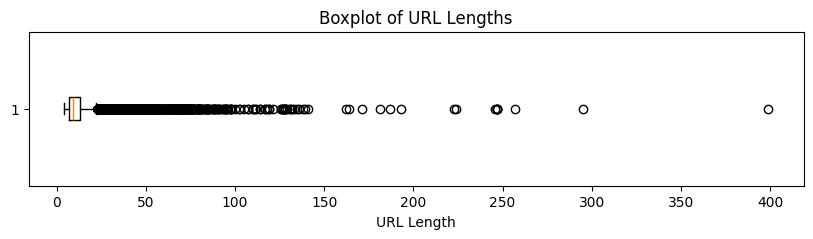

In [ ]:
token_lengths = [len(url_tokenizer(url)) for url in train_df['URL']]
plt.figure(figsize=(10, 2))


data = token_lengths

plt.boxplot(data, vert=False)
plt.xlabel("URL Length")
plt.title("Boxplot of URL Lengths")
plt.show()

Outliers seems heavy above 30 to 40 so we will use 35 as maximum length for word embeddings

In [ ]:
class URLDatasetWord(Dataset):
    def __init__(self, urls, labels, vocab, max_len=35):
        self.urls = urls
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        tokens = url_tokenizer(self.urls[idx])
        indices = self.vocab(tokens)[:self.max_len]
        # pad to max_len
        padded = indices + [0] * (self.max_len - len(indices))
        return torch.tensor(padded, dtype=torch.long), \
               torch.tensor(self.labels[idx], dtype=torch.float)

In [ ]:
class CNN_Fasttext(nn.Module):
  """CNN_Faststext embeddings"""
  # create charCNN constructor
  def __init__(self, embedding_matrix, num_filters=128, kernel_sizes=[3,5,7], dropout=0.3):
  # since we have a batch size of 256 URL each is padded or truncated to length 35 token each token is represented by 300 embedding vector the resulting tensor is [256,35,300]
    super(CNN_Fasttext, self).__init__()

    vocab_size, embed_dim = embedding_matrix.shape

    self.embedding = nn.Embedding.from_pretrained(
        embedding_matrix,
        freeze = False,
        padding_idx = 0
    )
    # three 1D convlution layers each look at different subset using kernels  of 3 , 5 , 7 to capture diffent url words
    self.convs = nn.ModuleList([
        nn.Conv1d(embed_dim , num_filters, k, padding = k//2)
        for k in kernel_sizes
    ])

    # batch normalization for each of the three kernel each has 128 filter /feature
    self.batch_norms = nn.ModuleList([
        nn.BatchNorm1d(num_filters) for _ in kernel_sizes
    ])

    # apply dropout to stablize training and prvent overfitting
    self.dropout = nn.Dropout(dropout)

    # the fully connected layer
    conv_out_size = num_filters * len(kernel_sizes) # 128 * 3
    self.fc1 = nn.Linear(conv_out_size,128)
    # the output layer mapping the 128 to 1 output it is linear to get
    self.fc2 = nn.Linear(128,1)

  def forward(self, x):
    x = self.embedding(x)
    x = x.permute(0,2,1) # as convolution layer expect (256 , 300 , 35 ) ( batch size, embedding , max sequence length)

    conv_outputs = []
    # applying the forward pass for batch x
    for conv, bn in zip(self.convs ,self.batch_norms):
      conv_out = conv(x)
      conv_out = bn(conv_out)
      conv_out = F.relu(conv_out)
      # each filter become one number per URL in batch
      conv_out = F.max_pool1d(conv_out, conv_out.size(2))
      conv_out = conv_out.squeeze(2)

      conv_outputs.append(conv_out) # list of tensors for each kernel

    x = torch.cat(conv_outputs, dim=1) # combine conv_ouputs in one tensor [batch , 128*3]features
    x = self.dropout(x) # apply drop out
    x = F.relu(self.fc1(x)) # relu fully connected layer 1 to reduce 128*3 to 128
    x = self.dropout(x) # dropout
    x = self.fc2(x)  # fully connected layer 2 to produce output 128 to 1
    return x.squeeze(1) # remove the extra dimension

In [ ]:
device = torch.device('cpu')
fasttext_cnn = CNN_Fasttext(embedding_matrix=embedding_matrix).to(device)
print(f"fasttext_cnn parameters: {sum(p.numel() for p in fasttext_cnn.parameters()):,}")

fasttext_cnn parameters: 5,339,861


In [ ]:
print(f"Vocab size: {len(url_vocab):,}")

Vocab size: 15,711


In [ ]:
# Create word-level datasets and dataloaders for FastText CNN
MAX_LEN_WORD = 35

train_dataset_word = URLDatasetWord(train_df['URL'].values, train_df['Label'].values, url_vocab, MAX_LEN_WORD)
val_dataset_word = URLDatasetWord(val_df['URL'].values, val_df['Label'].values, url_vocab, MAX_LEN_WORD)

# Handle class imbalance with weighted sampler (using the same logic as before)
class_weights_word = {0: 1.0/class_counts[0], 1: 1.0/class_counts[1]}
sample_weights_word = [class_weights_word[label] for label in train_df['Label'].values]
sampler_word = WeightedRandomSampler(sample_weights_word, len(sample_weights_word))

train_loader_word = DataLoader(train_dataset_word, batch_size=batch_size, sampler=sampler_word, num_workers=0)
val_loader_word = DataLoader(val_dataset_word, batch_size=batch_size, shuffle=False, num_workers=0)


In [ ]:

fasttext_cnn = CNN_Fasttext(embedding_matrix=embedding_matrix).to(device)
history_fastcnn, metrics_fastcnn = train_model(
    fasttext_cnn, train_loader_word, val_loader_word, epochs= 15, model_name="cnn_fasttext_(1)"
)


Training Fasttext-cnn


evaluation: 100%|██████████| 77/77 [00:18<00:00,  4.21it/s]


Epoch 1/15
  Train Loss: 0.0435, Acc: 0.9868, F1: 0.9869
  Val Loss: 0.0316, Acc: 0.9917, F1: 0.9902
 Checkpoint saved (F1: 0.9902)


evaluation: 100%|██████████| 77/77 [00:17<00:00,  4.45it/s]


Epoch 2/15
  Train Loss: 0.0197, Acc: 0.9943, F1: 0.9944
  Val Loss: 0.0283, Acc: 0.9930, F1: 0.9918
 Checkpoint saved (F1: 0.9918)


...

Epoch 13/15
  Train Loss: 0.0113, Acc: 0.9965, F1: 0.9966
  Val Loss: 0.0317, Acc: 0.9930, F1: 0.9917


evaluation: 100%|██████████| 77/77 [00:18<00:00,  4.17it/s]


Epoch 14/15
  Train Loss: 0.0128, Acc: 0.9961, F1: 0.9961
  Val Loss: 0.0322, Acc: 0.9931, F1: 0.9919


evaluation: 100%|██████████| 77/77 [00:17<00:00,  4.36it/s]


Epoch 15/15
  Train Loss: 0.0118, Acc: 0.9963, F1: 0.9963
  Val Loss: 0.0313, Acc: 0.9931, F1: 0.9918


In [ ]:
# load checkpoint
cnnfasttext = CNN_Fasttext(embedding_matrix=embedding_matrix).to(device)
cnnfasttext_checkpoint = torch.load('cnn_fasttext_(1).pth', map_location='cpu', weights_only=False)
cnnfasttext.load_state_dict(cnnfasttext_checkpoint['model_state_dict'])
cnnfasttext.eval()

# define criterion since it lives inside train_model
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# evaluate using the model, not the checkpoint dict
val_loss, val_preds, val_labels = evaluate(cnnfasttext, val_loader_word, criterion, device)
metric_cnn_fasttext = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [00:14<00:00,  5.34it/s]


# Model (4): Hybrid Feature Fusion

In [ ]:
train_features = pd.read_csv("train_features.csv")
test_features = pd.read_csv("test_features.csv")
val_features = pd.read_csv("val_features.csv")

In [ ]:
# Make sure URL order in train_df matches train_feat row order
# If  the split (same RANDOM_STATE=42), they align.
assert len(train_df) == len(train_features), "Row count mismatch!"
assert (train_features['Label'].values == train_df['Label'].values).all(), "Label mismatch!"
print("Alignment confirmed")

Alignment confirmed


In [ ]:
train_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90843 entries, 0 to 90842
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   url_length                90843 non-null  int64  
 1   hostname_length           90843 non-null  int64  
 2   path_length               90843 non-null  int64  
 3   query_length              90843 non-null  int64  
 4   num_dots                  90843 non-null  int64  
 5   num_hyphens               90843 non-null  int64  
 6   num_underscores           90843 non-null  int64  
 7   num_slashes               90843 non-null  int64  
 8   num_at_symbol             90843 non-null  int64  
 9   num_question_marks        90843 non-null  int64  
 10  num_equals                90843 non-null  int64  
 11  num_ampersand             90843 non-null  int64  
 12  num_percent               90843 non-null  int64  
 13  num_digits                90843 non-null  int64  
 14  digit_

In [ ]:
class URL_Datset_Fusion(Dataset):

  def __init__(self, df, feat_df ,vocab, max_len =200 , augment =False, feature_cols=None):
    self.urls = df['URL'].values
    self.labels = df['Label'].values
    cols = feature_cols if feature_cols is not None else [c for c in feat_df.columns if c != 'Label']
    self.features = feat_df[cols].values.astype(np.float32)
    self.vocab = vocab
    self.max_len = max_len
    self.augment = augment

  def __len__(self):
    return len(self.urls)


  def __getitem__(self, idx):

    url = self.urls[idx] # get url by index from the urls dictionary
    label = self.labels[idx]  # get label by index from the label dictionary
    encoded = self.vocab.encode(url, self.max_len, pad_to_max =True)#encode the url

    if self.augment and np.random.random() < 0.1: # augmentation happend occationally with probability 10%
      mask = np.random.random(len(encoded))<0.05 # only 5% of tokens are set to true in the mask
      for i in range(len(encoded)):
        if mask[i] and encoded[i]>1: # the index is selected by mask and encoded value is greater than one to avoid modifying pad 0 or unknown 1
          encoded[i] = self.vocab.unkown_idx  # replace the selected to token with unknown_idx 1 to make the model more robust

    stat_feature = self.features[idx] # adding the statistical features
    return torch.tensor(encoded,dtype= torch.long),torch.tensor(stat_feature, dtype = torch.float), torch.tensor(label, dtype = torch.float)


In [ ]:
class CharCNNFusion(nn.Module):
  """ Character-level CNN with multi-scale kernels and statistical feature fusion"""
  # create charCNN constructor
  def __init__(self , vocab_size, embed_dim = 64, num_filters=128, kernel_sizes=[3,5,7],stat_dim = 23, dropout=0.3):
  # since we have a batch size of 256 URL each is padded or truncated to length 200 token each token is represented by 64 embedding vector the resulting tensor is [256,200,64]
    super(CharCNNFusion, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim , padding_idx = 0) # embedding layer

    # three 1D convlution layers each look at different subset using kernels  of 3 , 5 , 7 to capture diffent url words
    self.convs = nn.ModuleList([
        nn.Conv1d(embed_dim , num_filters, k, padding = k//2)
        for k in kernel_sizes
    ])

    # batch normalization for each of the three kernel each has 128 filter /feature
    self.batch_norms = nn.ModuleList([
        nn.BatchNorm1d(num_filters) for _ in kernel_sizes
    ])

    # apply dropout to stablize training and prvent overfitting
    self.dropout = nn.Dropout(dropout)

    # the fully connected layer
    conv_out_size = num_filters * len(kernel_sizes) # 128 * 3
    self.fc1 = nn.Linear(conv_out_size,128)

    # adding a statistical feature branch
    self.stat_proj = nn.Sequential(
        nn.Linear(stat_dim, 64),
        nn.ReLU(),
        nn.Dropout(dropout)
    )

    # fusion by concatinating the deep features with the statistical features
    self.fusion = nn.Sequential(
        nn.Linear(128+64 , 64),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(64,1) # final output
    )


  def forward(self, x_deep , x_stat):
    x = self.embedding(x_deep)
    x = x.permute(0,2,1) # as convolution layer expect (256 , 64 , 200 ) ( batch size, embedding , max sequence length)

    conv_outputs = []
    # applying the forward pass for batch x
    for conv, bn in zip(self.convs ,self.batch_norms):
      conv_out = conv(x)
      conv_out = bn(conv_out)
      conv_out = F.relu(conv_out)
      # each filter become one number per URL in batch
      conv_out = F.max_pool1d(conv_out, conv_out.size(2)) # max pooling keep the strongest feature for each token instead of keeping the 200 tokens only the 128 vector is preserved with single max value indicating wether this feature appeared at all not its position
      conv_out = conv_out.squeeze(2) # removing the unnessary 3rd dimesion of 1 it is a matrix now

      conv_outputs.append(conv_out) # list of tensors for each kernel

    x = torch.cat(conv_outputs, dim=1) # combine conv_ouputs in one tensor [batch , 128*3]features
    x = self.dropout(x) # apply drop out
    x_deep = F.relu(self.fc1(x)) # relu fully connected layer 1 to reduce 128*3 to 128 [batch , 128]

    x_stat = self.stat_proj(x_stat) # [batch , 64]
    x_fused = torch.cat([x_deep , x_stat] , 1) # [batch , 64+128]

    return self.fusion(x_fused).squeeze(1) # Apply fusion layer and squeeze to remove extra dimension

In [ ]:
train_dataset = URL_Datset_Fusion(train_df, train_features, vocab, MAX_LEN, augment=True )
val_dataset   = URL_Datset_Fusion(val_df,   val_features,   vocab, MAX_LEN, augment=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)

In [ ]:
def train_epoch_fusion(model ,loader, optimizer, criterion, device):
  model.train()
  total_loss = 0
  all_preds = []
  all_labels = []

  for batch in tqdm(loader, desc ='Trainig'): # tqdm to print progress while training is running

      x_deep, x_stat, y = batch #  unpack three values
      x_deep, x_stat, y = x_deep.to(device), x_stat.to(device), y.to(device) # move data to cpu or Gpu
      optimizer.zero_grad() # clear old gradient before calculating new one it is saved by defualt
      outputs = model(x_deep, x_stat) # Pass both deep and statistical features to the model

      loss = criterion(outputs, y) # calculate error with BCEWithLogitsLoss
      loss.backward() # compute model with respect to all model parameters
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #limit gradient to maximum norm 1 prevent exploding gradients
      optimizer.step() # update weights with optimizer

      total_loss += loss.item() # save total batch loss
      preds = (torch.sigmoid(outputs) > 0.5).float() # convert logits to predictions 1 or 0
      all_preds.extend(preds.cpu().numpy()) # move preds to cpu or gpu
      all_labels.extend(y.cpu().numpy()) # store actual labels for metric computation

  return total_loss / len(loader), all_preds, all_labels


In [ ]:
def evaluate_fusion(model,loader,criterion, device):
  model.eval()
  total_loss = 0
  all_preds = []
  all_labels = []

  with torch.no_grad(): # no gradient is needed in evaluation phase
    for batch in tqdm(loader , desc="evaluation"):
        x_deep, x_stat, y = batch #  unpack three values
        x_deep, x_stat, y = x_deep.to(device), x_stat.to(device), y.to(device)
        outputs = model(x_deep, x_stat) # Pass both deep and statistical features to the model

        loss = criterion(outputs, y)
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    return total_loss / len(loader), all_preds, all_labels


In [ ]:
fusion_model = CharCNNFusion(vocab_size=len(vocab.char2idx)).to(device)
history_fusion, metrics_fusion = train_model(
    fusion_model, train_loader, val_loader, epochs=15, model_name="cnn_fusion",
    train_epoch_func=train_epoch_fusion, evaluate_func=evaluate_fusion
)


Training Fusion_Model


evaluation: 100%|██████████| 77/77 [00:20<00:00,  3.71it/s]


Epoch 1/15
  Train Loss: 0.2210, Acc: 0.9217, F1: 0.9232
  Val Loss: 0.0674, Acc: 0.9802, F1: 0.9765
 Checkpoint saved (F1: 0.9765)


evaluation: 100%|██████████| 77/77 [00:20<00:00,  3.70it/s]


Epoch 2/15
  Train Loss: 0.1022, Acc: 0.9686, F1: 0.9689
  Val Loss: 0.0537, Acc: 0.9838, F1: 0.9809
 Checkpoint saved (F1: 0.9809)


...

Epoch 13/15
  Train Loss: 0.0270, Acc: 0.9918, F1: 0.9918
  Val Loss: 0.0305, Acc: 0.9924, F1: 0.9910
 Checkpoint saved (F1: 0.9910)


evaluation: 100%|██████████| 77/77 [00:21<00:00,  3.61it/s]


Epoch 14/15
  Train Loss: 0.0201, Acc: 0.9942, F1: 0.9942
  Val Loss: 0.0312, Acc: 0.9936, F1: 0.9924
 Checkpoint saved (F1: 0.9924)


evaluation: 100%|██████████| 77/77 [00:21<00:00,  3.65it/s]


Epoch 15/15
  Train Loss: 0.0165, Acc: 0.9957, F1: 0.9957
  Val Loss: 0.0349, Acc: 0.9931, F1: 0.9918


In [ ]:
# load checkpoint
cnn_fusion = CharCNNFusion(vocab_size=len(vocab.char2idx)).to(device)
cnn_fusion_checkpoint = torch.load('cnn_fusion.pth', map_location='cpu', weights_only=False)
cnn_fusion.load_state_dict(cnn_fusion_checkpoint['model_state_dict'])
cnn_fusion.eval()


pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight);

# evaluate using the model
val_loss, val_preds, val_labels = evaluate_fusion(cnn_fusion, val_loader, criterion, device)
metric_cnn_fusion = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [00:39<00:00,  1.95it/s]


In [ ]:

results = {
    'Model': ['Char-CNN','CNN-Fasttext','CNN-BiLSTM','Hybrid Fusion'],
    'Params (M)': [
         sum(p.numel() for p in charcnn.parameters()) / 1e6,
        sum(p.numel() for p in cnnfasttext.parameters()) / 1e6,
         sum(p.numel() for p in cnnlstm.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion.parameters()) / 1e6
],
    'Trained Params (M)': [
        trainable_non_embedding_params(charcnn) / 1e6,
        trainable_non_embedding_params(cnnfasttext) / 1e6,
        trainable_non_embedding_params(cnnlstm) / 1e6,
        trainable_non_embedding_params(cnn_fusion) / 1e6
    ],

    'Accuracy': [ metric_cnn['Accuracy'],metric_cnn_fasttext['Accuracy'],metric_cnn_bilstm['Accuracy'],metric_cnn_fusion['Accuracy']],
    'Precision': [ metric_cnn['Precision'],metric_cnn_fasttext['Precision'] ,metric_cnn_bilstm['Precision'],metric_cnn_fusion['Precision']],
    'Recall': [ metric_cnn['Recall'],metric_cnn_fasttext['Recall'],metric_cnn_bilstm['Recall'],metric_cnn_fusion['Recall']],
    'F1 Score': [ metric_cnn['F1'],metric_cnn_fasttext['F1'] ,metric_cnn_bilstm['F1'],metric_cnn_fusion['F1'] ]
}

comparison_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))

# Efficiency (F1 per million params)
print("\n" + "-"*50)
print("EFFICIENCY ANALYSIS (F1 Score per Million Trained Parameters)")
print("-"*50)
for i, row in comparison_df.iterrows():
    efficiency = row['F1 Score'] / row['Trained Params (M)']
    print(f"{row['Model']:15} : {efficiency:.2f}")


MODEL PERFORMANCE 
        Model  Params (M)  Trained Params (M)  Accuracy  Precision   Recall  F1 Score
     Char-CNN    0.179329            0.173441  0.992192   0.988141 0.993431  0.990779
 CNN-Fasttext    5.339861            0.626561  0.993065   0.987812 0.995864  0.991822
   CNN-BiLSTM    0.360449            0.354561  0.993630   0.989835 0.995134  0.992478
Hybrid Fusion    0.193153            0.187265  0.993579   0.997175 0.987591  0.992360

--------------------------------------------------
EFFICIENCY ANALYSIS (F1 Score per Million Trained Parameters)
--------------------------------------------------
Char-CNN        : 5.71
CNN-Fasttext    : 1.58
CNN-BiLSTM      : 2.80
Hybrid Fusion   : 5.30


# Ablation Study for Hybrid Fusion Model
- CNN-char no features (our deeplearning baseline)
- All features
- Top quartile (top25) feature based on randomforest model feature importances
- Above Median features (top50)feature based on randomforest model feature importances

## Ablation study top Quartile 25%

In [ ]:
train_features = pd.read_csv("train_features.csv")
test_features = pd.read_csv("test_features.csv")
val_features = pd.read_csv("val_features.csv")

In [ ]:
train_features = train_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes']]

In [ ]:
val_features = val_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes']]

In [ ]:
feature_col_25 = train_features.columns.tolist()
train_dataset_25 = URL_Datset_Fusion(train_df, train_features, vocab, MAX_LEN, augment=True, feature_cols=feature_col_25)
val_dataset_25   = URL_Datset_Fusion(val_df,   val_features,   vocab, MAX_LEN, augment=False, feature_cols=feature_col_25)

train_loader_25 = DataLoader(train_dataset_25, batch_size=batch_size, sampler=sampler, num_workers=0)
val_loader_25   = DataLoader(val_dataset_25,   batch_size=batch_size, shuffle=False,   num_workers=0)

In [ ]:
fusion_model_25 = CharCNNFusion(vocab_size=len(vocab.char2idx), stat_dim=len(feature_col_25)).to(device)
history_fusion_25, metrics_fusion_25 = train_model(
    fusion_model_25, train_loader_25, val_loader_25, epochs=15, model_name="cnn_fusion_25",
    train_epoch_func=train_epoch_fusion, evaluate_func=evaluate_fusion
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cpu
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.



Training cnn_fusion_25


evaluation: 100%|██████████| 77/77 [00:35<00:00,  2.20it/s]


Epoch 1/15
  Train Loss: 0.2436, Acc: 0.9211, F1: 0.9221
  Val Loss: 0.0848, Acc: 0.9762, F1: 0.9716
 Checkpoint saved (F1: 0.9716)


evaluation: 100%|██████████| 77/77 [00:33<00:00,  2.29it/s]


...

Epoch 13/15
  Train Loss: 0.0270, Acc: 0.9920, F1: 0.9920
  Val Loss: 0.0309, Acc: 0.9930, F1: 0.9917


evaluation: 100%|██████████| 77/77 [00:35<00:00,  2.19it/s]


Epoch 14/15
  Train Loss: 0.0268, Acc: 0.9922, F1: 0.9923
  Val Loss: 0.0332, Acc: 0.9928, F1: 0.9915


evaluation: 100%|██████████| 77/77 [00:34<00:00,  2.24it/s]


Epoch 15/15
  Train Loss: 0.0249, Acc: 0.9926, F1: 0.9926
  Val Loss: 0.0286, Acc: 0.9927, F1: 0.9913


In [ ]:
cnn_fusion_25 = CharCNNFusion(vocab_size=len(vocab.char2idx), stat_dim=5).to(device)
cnn_fusion_25_checkpoint = torch.load('cnn_fusion_25.pth', map_location='cpu', weights_only=False)
cnn_fusion_25.load_state_dict(cnn_fusion_25_checkpoint['model_state_dict'])
cnn_fusion_25.eval()

pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# evaluate using the model
val_loss, val_preds, val_labels = evaluate_fusion(cnn_fusion_25, val_loader_25, criterion, device)
metric_cnn_fusion_25 = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [00:39<00:00,  1.97it/s]


## Ablation study top Quartile 50%

In [ ]:
train_features = pd.read_csv("train_features.csv")
test_features = pd.read_csv("test_features.csv")
val_features = pd.read_csv("val_features.csv")

In [ ]:
train_features = train_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes' ,'num_hyphens','hostname_has_hyphen','query_length','subdomain_depth']]

In [ ]:
val_features = val_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes' ,'num_hyphens','hostname_has_hyphen','query_length','subdomain_depth']]

In [ ]:
feature_col_50 = train_features.columns.tolist()
train_dataset_50 = URL_Datset_Fusion(train_df, train_features, vocab, MAX_LEN, augment=True, feature_cols=feature_col_50)
val_dataset_50   = URL_Datset_Fusion(val_df,   val_features,   vocab, MAX_LEN, augment=False, feature_cols=feature_col_50)

train_loader_50 = DataLoader(train_dataset_50, batch_size=batch_size, sampler=sampler, num_workers=0)
val_loader_50   = DataLoader(val_dataset_50,   batch_size=batch_size, shuffle=False,   num_workers=0)

In [ ]:
fusion_model_50 = CharCNNFusion(vocab_size=len(vocab.char2idx), stat_dim=len(feature_col)).to(device)
history_fusion, metrics_fusion = train_model(
    fusion_model_50, train_loader, val_loader, epochs=15, model_name="cnn_fusion_50",
    train_epoch_func=train_epoch_fusion, evaluate_func=evaluate_fusion
)


Training cnn_fusion_50


evaluation: 100%|██████████| 77/77 [00:29<00:00,  2.62it/s]


Epoch 1/15
  Train Loss: 0.2423, Acc: 0.9186, F1: 0.9200
  Val Loss: 0.0921, Acc: 0.9742, F1: 0.9700
 Checkpoint saved (F1: 0.9700)


evaluation: 100%|██████████| 77/77 [00:29<00:00,  2.63it/s]


Epoch 2/15
  Train Loss: 0.1104, Acc: 0.9662, F1: 0.9662
  Val Loss: 0.0753, Acc: 0.9767, F1: 0.9730
 Checkpoint saved (F1: 0.9730)


...

Epoch 13/15
  Train Loss: 0.0293, Acc: 0.9911, F1: 0.9911
  Val Loss: 0.0251, Acc: 0.9932, F1: 0.9919


evaluation: 100%|██████████| 77/77 [00:30<00:00,  2.51it/s]


Epoch 14/15
  Train Loss: 0.0262, Acc: 0.9920, F1: 0.9920
  Val Loss: 0.0285, Acc: 0.9938, F1: 0.9927
 Checkpoint saved (F1: 0.9927)


evaluation: 100%|██████████| 77/77 [00:30<00:00,  2.50it/s]


Epoch 15/15
  Train Loss: 0.0266, Acc: 0.9928, F1: 0.9928
  Val Loss: 0.0297, Acc: 0.9932, F1: 0.9919


In [ ]:
cnn_fusion_50 = CharCNNFusion(vocab_size=len(vocab.char2idx), stat_dim=9).to(device)
cnn_fusion_50_checkpoint = torch.load('cnn_fusion_50.pth', map_location='cpu', weights_only=False)
cnn_fusion_50.load_state_dict(cnn_fusion_50_checkpoint['model_state_dict'])
cnn_fusion_50.eval()

# define criterion since it lives inside train_model
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# evaluate using the model
val_loss, val_preds, val_labels = evaluate_fusion(cnn_fusion_50, val_loader_50, criterion, device)
metric_cnn_fusion_50 = compute_metrics(val_labels, val_preds)

evaluation: 100%|██████████| 77/77 [00:38<00:00,  1.99it/s]


In [ ]:

results = {
    'Model': ['Char-CNN','Hybrid Fusion Top 25','Hybrid Fusion Top 50','Hybrid Fusion Full Features'],
    'Params (M)': [
         sum(p.numel() for p in char_cnn.parameters()) / 1e6,
        sum(p.numel() for p in cnn_fusion_25.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion_50.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion.parameters()) / 1e6
],
    'Trained Params (M)': [
        trainable_non_embedding_params(charcnn) / 1e6,
        trainable_non_embedding_params(cnn_fusion_25) / 1e6,
        trainable_non_embedding_params(cnn_fusion_50) / 1e6,
        trainable_non_embedding_params(cnn_fusion) / 1e6
    ],

    'Accuracy': [ metric_cnn['Accuracy'],metric_cnn_fusion_25['Accuracy'],metric_cnn_fusion_50['Accuracy'],metric_cnn_fusion['Accuracy']],
    'Precision': [ metric_cnn['Precision'],metric_cnn_fusion_25['Precision'] ,metric_cnn_fusion_50['Precision'],metric_cnn_fusion['Precision']],
    'Recall': [ metric_cnn['Recall'],metric_cnn_fusion_25['Recall'],metric_cnn_fusion_50['Recall'],metric_cnn_fusion['Recall']],
    'F1 Score': [ metric_cnn['F1'],metric_cnn_fusion_25['F1'] ,metric_cnn_fusion_50['F1'],metric_cnn_fusion['F1'] ]
}

comparison_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))

# Efficiency (F1 per million params)
print("\n" + "-"*50)
print("EFFICIENCY ANALYSIS (F1 Score per Million Trained Parameters)")
print("-"*50)
for i, row in comparison_df.iterrows():
    efficiency = row['F1 Score'] / row['Trained Params (M)']
    print(f"{row['Model']:15} : {efficiency:.2f}")


MODEL PERFORMANCE 
                      Model  Params (M)  Trained Params (M)  Accuracy  Precision   Recall  F1 Score
                   Char-CNN    0.179329            0.173441  0.993322   0.995832 0.988321  0.992063
       Hybrid Fusion Top 25    0.192001            0.186113  0.993065   0.993771 0.989781  0.991772
       Hybrid Fusion Top 50    0.192257            0.186369  0.993835   0.994626 0.990754  0.992686
Hybrid Fusion Full Features    0.193153            0.187265  0.993579   0.997175 0.987591  0.992360

--------------------------------------------------
EFFICIENCY ANALYSIS (F1 Score per Million Trained Parameters)
--------------------------------------------------
Char-CNN        : 5.72
Hybrid Fusion Top 25 : 5.33
Hybrid Fusion Top 50 : 5.33
Hybrid Fusion Full Features : 5.30


# Final Evaluation on Test Sets

1. Original Test Set
2. Balanced Test Set
3. Imbalanced Test Set (80/20)

In [ ]:
def inference(model, loader, n_batches =15, is_fusion =False):
  """ average inference time in milisonds no tqdm overhed """

  model.eval()
  times =[] # saving times for each batch



  with torch.no_grad():
    for i, batch in enumerate(loader):
      if i >= n_batches:
        break
      if is_fusion:

        x_deep, x_stat, _ = batch
        x_deep, x_stat = x_deep.to(device), x_stat.to(device)
        start = time.time()
        output = model(x_deep, x_stat) # pass both deep and statistical features to the model
        end = time.time()


      else :

        x, _ = batch
        x = x.to(device)
        start = time.time()
        output = model(x)
        end = time.time()
      times.append((end - start) / len(batch[0]) * 1000)  # ms per URL

  return round(sum(times) / len(times), 4)


## Loading all models checkpoints

In [ ]:
# load checkpoint
charcnn = CharCNN(vocab_size=len(vocab.char2idx)).to(device)
charcnn_checkpoint = torch.load('char_cnn_best.pth', map_location='cpu', weights_only=False)
charcnn.load_state_dict(charcnn_checkpoint['model_state_dict'])
charcnn.eval()


CharCNN(
  (embedding): Embedding(92, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
# define criterion since it lives inside train_model
pos_weight = torch.tensor([class_counts[0] / class_counts[1]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
# load checkpoint
cnnlstm = CNN_LSTM(vocab_size=len(vocab.char2idx)).to(device)
cnnlstm_checkpoint = torch.load('cnn_bilstm_best.pth', map_location='cpu', weights_only=False)
cnnlstm.load_state_dict(cnnlstm_checkpoint['model_state_dict'])
cnnlstm.eval()

CNN_LSTM(
  (embedding): Embedding(92, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(384, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
# load checkpoint
cnnfasttext = CNN_Fasttext(embedding_matrix=embedding_matrix).to(device)
cnnfasttext_checkpoint = torch.load('cnn_fasttext_(1).pth', map_location='cpu', weights_only=False)
cnnfasttext.load_state_dict(cnnfasttext_checkpoint['model_state_dict'])
cnnfasttext.eval()

CNN_Fasttext(
  (embedding): Embedding(15711, 300, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(300, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(300, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(300, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
# load checkpoint
cnn_fusion = CharCNNFusion(vocab_size=len(vocab.char2idx)).to(device)
cnn_fusion_checkpoint = torch.load('cnn_fusion.pth', map_location='cpu', weights_only=False)
cnn_fusion.load_state_dict(cnn_fusion_checkpoint['model_state_dict'])
cnn_fusion.eval()


CharCNNFusion(
  (embedding): Embedding(92, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (stat_proj): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
# load checkpoint
cnn_fusion_25 = CharCNNFusion(vocab_size=len(vocab.char2idx), stat_dim=5).to(device)
cnn_fusion_25_checkpoint = torch.load('cnn_fusion_25.pth', map_location='cpu', weights_only=False)
cnn_fusion_25.load_state_dict(cnn_fusion_25_checkpoint['model_state_dict'])
cnn_fusion_25.eval()

CharCNNFusion(
  (embedding): Embedding(92, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (stat_proj): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
# load checkpoint
cnn_fusion_50 = CharCNNFusion(vocab_size=len(vocab.char2idx),stat_dim=9).to(device)
cnn_fusion_50_checkpoint = torch.load('cnn_fusion_50.pth', map_location='cpu', weights_only=False)
cnn_fusion_50.load_state_dict(cnn_fusion_50_checkpoint['model_state_dict'])
cnn_fusion_50.eval()

CharCNNFusion(
  (embedding): Embedding(92, 64, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (2): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
  )
  (batch_norms): ModuleList(
    (0-2): 3 x BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=384, out_features=128, bias=True)
  (stat_proj): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

## Orginal Test set

In [ ]:

test_df = pd.read_csv("test.csv")
test_dataset = URLDataset(test_df, vocab, MAX_LEN, augment=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers= 0)

### Char-CNN

In [ ]:
# evaluate using the model
test_loss, test_preds, test_labels = evaluate(charcnn, test_loader, criterion, device)
metric_cnn = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [00:41<00:00,  1.87it/s]


Architecture Review

In [ ]:
for name, param in charcnn.named_parameters():
    print(name, param.shape)

embedding.weight torch.Size([92, 64])
convs.0.weight torch.Size([128, 64, 3])
convs.0.bias torch.Size([128])
convs.1.weight torch.Size([128, 64, 5])
convs.1.bias torch.Size([128])
convs.2.weight torch.Size([128, 64, 7])
convs.2.bias torch.Size([128])
batch_norms.0.weight torch.Size([128])
batch_norms.0.bias torch.Size([128])
batch_norms.1.weight torch.Size([128])
batch_norms.1.bias torch.Size([128])
batch_norms.2.weight torch.Size([128])
batch_norms.2.bias torch.Size([128])
fc1.weight torch.Size([128, 384])
fc1.bias torch.Size([128])
fc2.weight torch.Size([1, 128])
fc2.bias torch.Size([1])


In [ ]:
cnn_time = inference(charcnn,test_loader)

In [ ]:
cnn_time

2.0575

### Bilstm + CNN

In [ ]:
# evaluate using the model
test_loss, test_preds, test_labels = evaluate(cnnlstm, test_loader, criterion, device)
metric_cnn_bilstm = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [01:48<00:00,  1.41s/it]


In [ ]:
for name, param in cnnlstm.named_parameters():
    print(name, param.shape)

embedding.weight torch.Size([92, 64])
convs.0.weight torch.Size([128, 64, 3])
convs.0.bias torch.Size([128])
convs.1.weight torch.Size([128, 64, 5])
convs.1.bias torch.Size([128])
convs.2.weight torch.Size([128, 64, 7])
convs.2.bias torch.Size([128])
batch_norms.0.weight torch.Size([128])
batch_norms.0.bias torch.Size([128])
batch_norms.1.weight torch.Size([128])
batch_norms.1.bias torch.Size([128])
batch_norms.2.weight torch.Size([128])
batch_norms.2.bias torch.Size([128])
lstm.weight_ih_l0 torch.Size([256, 384])
lstm.weight_hh_l0 torch.Size([256, 64])
lstm.bias_ih_l0 torch.Size([256])
lstm.bias_hh_l0 torch.Size([256])
lstm.weight_ih_l0_reverse torch.Size([256, 384])
lstm.weight_hh_l0_reverse torch.Size([256, 64])
lstm.bias_ih_l0_reverse torch.Size([256])
lstm.bias_hh_l0_reverse torch.Size([256])
fc.weight torch.Size([1, 128])
fc.bias torch.Size([1])


### Fasttext + CNN

In [ ]:
def url_tokenizer(url):
    import re
    return re.split(r'[/.\-_?=&]', url.lower())


from torchtext.vocab import build_vocab_from_iterator

def yield_tokens(urls):
    for url in urls:
        yield url_tokenizer(url)

url_vocab = build_vocab_from_iterator(
    yield_tokens(train_df['URL']), # Corrected: iterate over the 'URL' column
    specials=['<pad>', '<unk>'],
    min_freq=3
)
url_vocab.set_default_index(url_vocab['<unk>'])

In [ ]:
ft = vocab_module.FastText(language='en')

embed_dim = 300  # fasttext is always 300 dimension
vocab_size = len(url_vocab)

# Initialize embedding_matrix with small random values for all tokens
# This provides unique starting points for out-of-vocabulary words.
std_dev = 0.1 # Standard deviation for random initialization
embedding_matrix = torch.randn(vocab_size, embed_dim) * std_dev

for token, idx in url_vocab.get_stoi().items():
    if token in ft.stoi:
        embedding_matrix[idx] = ft.vectors[ft.stoi[token]]

# Ensure the padding token (index 0) remains a zero vector
embedding_matrix[url_vocab['<pad>']] = torch.zeros(embed_dim)

In [ ]:
# Create word-level test dataset and dataloader for FastText CNN
MAX_LEN_WORD = 35
test_dataset_word = URLDatasetWord(test_df['URL'].values, test_df['Label'].values, url_vocab, MAX_LEN_WORD)
test_loader_word = DataLoader(test_dataset_word, batch_size=batch_size, shuffle=False, num_workers=0)

# evaluate using the model, using the word-level test loader
test_loss, test_preds, test_labels = evaluate(cnnfasttext, test_loader_word, criterion, device)
metric_cnn_fasttext = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [00:17<00:00,  4.43it/s]


In [ ]:
for name, param in cnnfasttext.named_parameters():
    print(name, param.shape)

embedding.weight torch.Size([15711, 300])
convs.0.weight torch.Size([128, 300, 3])
convs.0.bias torch.Size([128])
convs.1.weight torch.Size([128, 300, 5])
convs.1.bias torch.Size([128])
convs.2.weight torch.Size([128, 300, 7])
convs.2.bias torch.Size([128])
batch_norms.0.weight torch.Size([128])
batch_norms.0.bias torch.Size([128])
batch_norms.1.weight torch.Size([128])
batch_norms.1.bias torch.Size([128])
batch_norms.2.weight torch.Size([128])
batch_norms.2.bias torch.Size([128])
fc1.weight torch.Size([128, 384])
fc1.bias torch.Size([128])
fc2.weight torch.Size([1, 128])
fc2.bias torch.Size([1])


### Hybrid Fusion Models

In [ ]:

test_features = pd.read_csv("test_features.csv")


In [ ]:

test_df = pd.read_csv("test.csv")
test_features = test_features.drop('Label',axis=1)
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)
test_loader_all  = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)

In [ ]:
# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion, test_loader_all, criterion, device)
metric_cnn_fusion = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [00:39<00:00,  1.94it/s]


In [ ]:
for name, param in cnn_fusion.named_parameters():
    print(name, param.shape)

embedding.weight torch.Size([92, 64])
convs.0.weight torch.Size([128, 64, 3])
convs.0.bias torch.Size([128])
convs.1.weight torch.Size([128, 64, 5])
convs.1.bias torch.Size([128])
convs.2.weight torch.Size([128, 64, 7])
convs.2.bias torch.Size([128])
batch_norms.0.weight torch.Size([128])
batch_norms.0.bias torch.Size([128])
batch_norms.1.weight torch.Size([128])
batch_norms.1.bias torch.Size([128])
batch_norms.2.weight torch.Size([128])
batch_norms.2.bias torch.Size([128])
fc1.weight torch.Size([128, 384])
fc1.bias torch.Size([128])
stat_proj.0.weight torch.Size([64, 23])
stat_proj.0.bias torch.Size([64])
fusion.0.weight torch.Size([64, 192])
fusion.0.bias torch.Size([64])
fusion.3.weight torch.Size([1, 64])
fusion.3.bias torch.Size([1])


Hybrid Fusion top quartile

In [ ]:
train_features = pd.read_csv("train_features.csv")
test_features = pd.read_csv("test_features.csv")
val_features = pd.read_csv("val_features.csv")

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes']]

In [ ]:
test_df = pd.read_csv("test.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)
test_loader_25   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)

In [ ]:
# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_25, test_loader_25, criterion, device)
metric_cnn_fusion_25 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [00:38<00:00,  1.99it/s]


In [ ]:
for name, param in cnn_fusion_25.named_parameters():
    print(name, param.shape)

embedding.weight torch.Size([92, 64])
convs.0.weight torch.Size([128, 64, 3])
convs.0.bias torch.Size([128])
convs.1.weight torch.Size([128, 64, 5])
convs.1.bias torch.Size([128])
convs.2.weight torch.Size([128, 64, 7])
convs.2.bias torch.Size([128])
batch_norms.0.weight torch.Size([128])
batch_norms.0.bias torch.Size([128])
batch_norms.1.weight torch.Size([128])
batch_norms.1.bias torch.Size([128])
batch_norms.2.weight torch.Size([128])
batch_norms.2.bias torch.Size([128])
fc1.weight torch.Size([128, 384])
fc1.bias torch.Size([128])
stat_proj.0.weight torch.Size([64, 5])
stat_proj.0.bias torch.Size([64])
fusion.0.weight torch.Size([64, 192])
fusion.0.bias torch.Size([64])
fusion.3.weight torch.Size([1, 64])
fusion.3.bias torch.Size([1])


In [ ]:
train_features = pd.read_csv("train_features.csv")
test_features = pd.read_csv("test_features.csv")
val_features = pd.read_csv("val_features.csv")

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes' ,'num_hyphens','hostname_has_hyphen','query_length','subdomain_depth']]

In [ ]:
test_df = pd.read_csv("test.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_50   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)
# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_50, test_loader_50, criterion, device)
metric_cnn_fusion_50 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 77/77 [00:38<00:00,  2.00it/s]


### Test Results on orginal testset distribution

In [ ]:

results = {
    'Model': ['Char-CNN','CNN-Fasttext','CNN-BiLSTM','Hybrid Fusion-Full','Hybrid Fusion Top 25','Hybrid Fusion Top 50'],
    'Params (M)': [
         sum(p.numel() for p in charcnn.parameters()) / 1e6,
        sum(p.numel() for p in cnnfasttext.parameters()) / 1e6,
         sum(p.numel() for p in cnnlstm.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion.parameters()) / 1e6,
            sum(p.numel() for p in cnn_fusion_25.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion_50.parameters()) / 1e6
],
    'Trained Params (M)': [
        trainable_non_embedding_params(charcnn) / 1e6,
        trainable_non_embedding_params(cnnfasttext) / 1e6,
        trainable_non_embedding_params(cnnlstm) / 1e6,
        trainable_non_embedding_params(cnn_fusion) / 1e6,
        trainable_non_embedding_params(cnn_fusion_25) / 1e6,
        trainable_non_embedding_params(cnn_fusion_50) / 1e6
    ],

    'Accuracy': [ metric_cnn['Accuracy'],metric_cnn_fasttext['Accuracy'],metric_cnn_bilstm['Accuracy'],metric_cnn_fusion['Accuracy'],metric_cnn_fusion_25['Accuracy'],metric_cnn_fusion_50['Accuracy']],
    'Precision': [ metric_cnn['Precision'],metric_cnn_fasttext['Precision'] ,metric_cnn_bilstm['Precision'],metric_cnn_fusion['Precision'],metric_cnn_fusion_25['Precision'],metric_cnn_fusion_50['Precision']],
    'Recall': [ metric_cnn['Recall'],metric_cnn_fasttext['Recall'],metric_cnn_bilstm['Recall'],metric_cnn_fusion['Recall'],metric_cnn_fusion_25['Recall'],metric_cnn_fusion_50['Recall']],
    'F1 Score': [ metric_cnn['F1'],metric_cnn_fasttext['F1'] ,metric_cnn_bilstm['F1'],metric_cnn_fusion['F1'],metric_cnn_fusion_25['F1'],metric_cnn_fusion_50['F1'] ],
     'TN': [metric_cnn['Confusion_Matrix'].ravel()[0],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[0],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[0]],
     'FP': [metric_cnn['Confusion_Matrix'].ravel()[1],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[1],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[1]],
     'FN': [metric_cnn['Confusion_Matrix'].ravel()[2],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[2],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[2]],
     'TP': [metric_cnn['Confusion_Matrix'].ravel()[3],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[3],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[3]],
    'Roc Auc Score': [ metric_cnn['Roc_Auc Score'],metric_cnn_fasttext['Roc_Auc Score'] ,metric_cnn_bilstm['Roc_Auc Score'],metric_cnn_fusion['Roc_Auc Score'],metric_cnn_fusion_25['Roc_Auc Score'],metric_cnn_fusion_50['Roc_Auc Score'] ],

    'ms per URL': [ inference(charcnn,test_loader),
                    inference(cnnfasttext,test_loader_word),
                    inference(cnnlstm,test_loader),
                    inference(cnn_fusion,test_loader_all, is_fusion=True),
                    inference(cnn_fusion_25,test_loader_25, is_fusion=True),
                    inference(cnn_fusion_50,test_loader_50, is_fusion=True)]
}

comparison_df = pd.DataFrame(results)
comparison_df['Efficiency (f1-score/M parameter)'] = comparison_df['F1 Score']/comparison_df['Trained Params (M)']
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))



MODEL PERFORMANCE 
               Model  Params (M)  Trained Params (M)  Accuracy  Precision   Recall  F1 Score    TN  FP  FN   TP  Roc Auc Score  ms per URL  Efficiency (f1-score/M parameter)
            Char-CNN    0.179329            0.173441  0.993733   0.994988 0.990147  0.992562 11205  41  81 8140       0.993251      2.0375                           5.722764
        CNN-Fasttext    5.339861            0.626561  0.994760   0.990455 0.997202  0.993817 11167  79  23 8198       0.995089      0.7775                           1.586146
          CNN-BiLSTM    0.360449            0.354561  0.993271   0.990065 0.994040  0.992049 11164  82  49 8172       0.993374      6.2729                           2.797963
  Hybrid Fusion-Full    0.193153            0.187265  0.993784   0.996445 0.988809  0.992612 11217  29  92 8129       0.993115      1.9102                           5.300577
Hybrid Fusion Top 25    0.192001            0.186113  0.993682   0.994263 0.990755  0.992506 11199  47  76 814

In [ ]:
comparison_df.to_csv("results_original_test_distribution.csv", index=False)

## Balanced Test set

In [ ]:
test_df = pd.read_csv("test_balanced.csv")
test_dataset = URLDataset(test_df, vocab, MAX_LEN, augment=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers= 0)

### Char-CNN

In [ ]:

# evaluate using the model, not the checkpoint dict
test_loss, test_preds, test_labels = evaluate(charcnn, test_loader, criterion, device)
metric_cnn = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [00:32<00:00,  1.98it/s]


### Bilstm + CNN

In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate(cnnlstm, test_loader, criterion, device)
metric_cnn_bilstm = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [01:19<00:00,  1.23s/it]


### Fasttext + CharCNN

In [ ]:
# Create word-level test dataset and dataloader for FastText CNN
MAX_LEN_WORD = 35

test_dataset_word = URLDatasetWord(test_df['URL'].values, test_df['Label'].values, url_vocab, MAX_LEN_WORD)

test_loader_word = DataLoader(test_dataset_word, batch_size=batch_size, shuffle=False, num_workers=0)

# evaluate using the model, using the word-level test loader
test_loss, test_preds, test_labels = evaluate(cnnfasttext, test_loader_word, criterion, device)
metric_cnn_fasttext = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [00:14<00:00,  4.41it/s]


### Hybrid Fusion Models

In [ ]:

test_features = pd.read_csv("test_balanced_features.csv")

In [ ]:
test_df = pd.read_csv("test_balanced.csv")
test_features = test_features.drop('Label',axis=1)
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_all   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion, test_loader_all, criterion, device)
metric_cnn_fusion = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [00:32<00:00,  1.98it/s]


In [ ]:

test_features = pd.read_csv("test_balanced_features.csv")
test_features = test_features.drop('Label',axis=1)

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes']]

In [ ]:
test_df = pd.read_csv("test_balanced.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_25   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_25, test_loader_25, criterion, device)
metric_cnn_fusion_25 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [00:32<00:00,  2.00it/s]


In [ ]:
test_features = pd.read_csv("test_balanced_features.csv")
test_features = test_features.drop('Label',axis=1)

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes' ,'num_hyphens','hostname_has_hyphen','query_length','subdomain_depth']]

In [ ]:
test_df = pd.read_csv("test_balanced.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_50   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_50, test_loader_50, criterion, device)
metric_cnn_fusion_50 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 65/65 [00:36<00:00,  1.77it/s]


### Test Results on Balanced testset distribution

In [ ]:

results = {
    'Model': ['Char-CNN','CNN-Fasttext','CNN-BiLSTM','Hybrid Fusion-Full','Hybrid Fusion Top 25','Hybrid Fusion Top 50'],
    'Params (M)': [
         sum(p.numel() for p in charcnn.parameters()) / 1e6,
        sum(p.numel() for p in cnnfasttext.parameters()) / 1e6,
         sum(p.numel() for p in cnnlstm.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion.parameters()) / 1e6,
            sum(p.numel() for p in cnn_fusion_25.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion_50.parameters()) / 1e6
],
    'Trained Params (M)': [
        trainable_non_embedding_params(charcnn) / 1e6,
        trainable_non_embedding_params(cnnfasttext) / 1e6,
        trainable_non_embedding_params(cnnlstm) / 1e6,
        trainable_non_embedding_params(cnn_fusion) / 1e6,
        trainable_non_embedding_params(cnn_fusion_25) / 1e6,
        trainable_non_embedding_params(cnn_fusion_50) / 1e6
    ],

    'Accuracy': [ metric_cnn['Accuracy'],metric_cnn_fasttext['Accuracy'],metric_cnn_bilstm['Accuracy'],metric_cnn_fusion['Accuracy'],metric_cnn_fusion_25['Accuracy'],metric_cnn_fusion_50['Accuracy']],
    'Precision': [ metric_cnn['Precision'],metric_cnn_fasttext['Precision'] ,metric_cnn_bilstm['Precision'],metric_cnn_fusion['Precision'],metric_cnn_fusion_25['Precision'],metric_cnn_fusion_50['Precision']],
    'Recall': [ metric_cnn['Recall'],metric_cnn_fasttext['Recall'],metric_cnn_bilstm['Recall'],metric_cnn_fusion['Recall'],metric_cnn_fusion_25['Recall'],metric_cnn_fusion_50['Recall']],
    'F1 Score': [ metric_cnn['F1'],metric_cnn_fasttext['F1'] ,metric_cnn_bilstm['F1'],metric_cnn_fusion['F1'],metric_cnn_fusion_25['F1'],metric_cnn_fusion_50['F1'] ],
     'TN': [metric_cnn['Confusion_Matrix'].ravel()[0],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[0],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[0]],
     'FP': [metric_cnn['Confusion_Matrix'].ravel()[1],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[1],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[1]],
     'FN': [metric_cnn['Confusion_Matrix'].ravel()[2],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[2],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[2]],
     'TP': [metric_cnn['Confusion_Matrix'].ravel()[3],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[3],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[3]],
    'Roc Auc Score': [ metric_cnn['Roc_Auc Score'],metric_cnn_fasttext['Roc_Auc Score'] ,metric_cnn_bilstm['Roc_Auc Score'],metric_cnn_fusion['Roc_Auc Score'],metric_cnn_fusion_25['Roc_Auc Score'],metric_cnn_fusion_50['Roc_Auc Score'] ],

    'ms per URL': [ inference(charcnn,test_loader),
                    inference(cnnfasttext,test_loader_word),
                    inference(cnnlstm,test_loader),
                    inference(cnn_fusion,test_loader_all, is_fusion=True),
                    inference(cnn_fusion_25,test_loader_25, is_fusion=True),
                    inference(cnn_fusion_50,test_loader_50, is_fusion=True)]
}

comparison_df = pd.DataFrame(results)
comparison_df['Efficiency (f1-score/M parameter)'] = comparison_df['F1 Score']/comparison_df['Trained Params (M)']
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))



MODEL PERFORMANCE 
               Model  Params (M)  Trained Params (M)  Accuracy  Precision   Recall  F1 Score   TN  FP  FN   TP  Roc Auc Score  ms per URL  Efficiency (f1-score/M parameter)
            Char-CNN    0.179329            0.173441  0.993431   0.996694 0.990147  0.993410 8194  27  81 8140       0.993431      1.9569                           5.727653
        CNN-Fasttext    5.339861            0.626561  0.995378   0.993577 0.997202  0.995386 8168  53  23 8198       0.995378      0.9155                           1.588650
          CNN-BiLSTM    0.360449            0.354561  0.993553   0.993073 0.994040  0.993556 8164  57  49 8172       0.993553      5.0554                           2.802215
  Hybrid Fusion-Full    0.193153            0.187265  0.993067   0.997301 0.988809  0.993037 8199  22  92 8129       0.993067      2.0842                           5.302843
Hybrid Fusion Top 25    0.192001            0.186113  0.993310   0.995843 0.990755  0.993293 8187  34  76 8145     

In [ ]:
comparison_df.to_csv("results_balanced_test_distribution.csv", index=False)

## ImBalanced Test set 80/20

In [ ]:

test_df = pd.read_csv("test_imbalanced_80_20.csv")
test_dataset = URLDataset(test_df, vocab, MAX_LEN, augment=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers= 0)

### Char-CNN

In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate(charcnn, test_loader, criterion, device)
metric_cnn = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [00:29<00:00,  1.86it/s]


### Bilstm + CNN

In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate(cnnlstm, test_loader, criterion, device)
metric_cnn_bilstm = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [01:10<00:00,  1.27s/it]


### Fasttext + CharCNN

In [ ]:
# Create word-level test dataset and dataloader for FastText CNN
MAX_LEN_WORD = 35

test_dataset_word = URLDatasetWord(test_df['URL'].values, test_df['Label'].values, url_vocab, MAX_LEN_WORD)

test_loader_word = DataLoader(test_dataset_word, batch_size=batch_size, shuffle=False, num_workers=0)

# evaluate using the model, using the word-level test loader
test_loss, test_preds, test_labels = evaluate(cnnfasttext, test_loader_word, criterion, device)
metric_cnn_fasttext = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [00:12<00:00,  4.25it/s]


### Hybrid Fusion Models

In [ ]:

test_features = pd.read_csv("test_imbalanced_80_20_features.csv")

In [ ]:
test_df = pd.read_csv("test_imbalanced_80_20.csv")
test_features = test_features.drop('Label',axis=1)
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_all   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion, test_loader_all, criterion, device)
metric_cnn_fusion = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [00:29<00:00,  1.89it/s]


In [ ]:

test_features = pd.read_csv("test_imbalanced_80_20_features.csv")
test_features = test_features.drop('Label',axis=1)

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes']]

In [ ]:
test_df = pd.read_csv("test_imbalanced_80_20.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_25   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


In [ ]:

# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_25, test_loader_25, criterion, device)
metric_cnn_fusion_25 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [00:28<00:00,  1.90it/s]


In [ ]:
test_features = pd.read_csv("test_imbalanced_80_20_features.csv")
test_features = test_features.drop('Label',axis=1)

In [ ]:
test_features = test_features[['path_length','hostname_length','shannon_entropy','url_length','num_slashes' ,'num_hyphens','hostname_has_hyphen','query_length','subdomain_depth']]

In [ ]:
test_df = pd.read_csv("test_imbalanced_80_20.csv")
feature_col = test_features.columns.tolist()
test_dataset   = URL_Datset_Fusion(test_df,   test_features,   vocab, MAX_LEN, augment=False)

test_loader_50   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,   num_workers=0)


# evaluate using the model
test_loss, test_preds, test_labels = evaluate_fusion(cnn_fusion_50, test_loader_50, criterion, device)
metric_cnn_fusion_50 = compute_metrics(test_labels, test_preds)

evaluation: 100%|██████████| 55/55 [00:27<00:00,  1.98it/s]


### Test Results on ImBalanced testset distribution

In [ ]:

results = {
    'Model': ['Char-CNN','CNN-Fasttext','CNN-BiLSTM','Hybrid Fusion-Full','Hybrid Fusion Top 25','Hybrid Fusion Top 50'],
    'Params (M)': [
         sum(p.numel() for p in charcnn.parameters()) / 1e6,
        sum(p.numel() for p in cnnfasttext.parameters()) / 1e6,
         sum(p.numel() for p in cnnlstm.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion.parameters()) / 1e6,
            sum(p.numel() for p in cnn_fusion_25.parameters()) / 1e6,
         sum(p.numel() for p in cnn_fusion_50.parameters()) / 1e6
],
    'Trained Params (M)': [
        trainable_non_embedding_params(charcnn) / 1e6,
        trainable_non_embedding_params(cnnfasttext) / 1e6,
        trainable_non_embedding_params(cnnlstm) / 1e6,
        trainable_non_embedding_params(cnn_fusion) / 1e6,
        trainable_non_embedding_params(cnn_fusion_25) / 1e6,
        trainable_non_embedding_params(cnn_fusion_50) / 1e6
    ],

    'Accuracy': [ metric_cnn['Accuracy'],metric_cnn_fasttext['Accuracy'],metric_cnn_bilstm['Accuracy'],metric_cnn_fusion['Accuracy'],metric_cnn_fusion_25['Accuracy'],metric_cnn_fusion_50['Accuracy']],
    'Precision': [ metric_cnn['Precision'],metric_cnn_fasttext['Precision'] ,metric_cnn_bilstm['Precision'],metric_cnn_fusion['Precision'],metric_cnn_fusion_25['Precision'],metric_cnn_fusion_50['Precision']],
    'Recall': [ metric_cnn['Recall'],metric_cnn_fasttext['Recall'],metric_cnn_bilstm['Recall'],metric_cnn_fusion['Recall'],metric_cnn_fusion_25['Recall'],metric_cnn_fusion_50['Recall']],
    'F1 Score': [ metric_cnn['F1'],metric_cnn_fasttext['F1'] ,metric_cnn_bilstm['F1'],metric_cnn_fusion['F1'],metric_cnn_fusion_25['F1'],metric_cnn_fusion_50['F1'] ],
     'TN': [metric_cnn['Confusion_Matrix'].ravel()[0],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[0],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[0],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[0]],
     'FP': [metric_cnn['Confusion_Matrix'].ravel()[1],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[1],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[1],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[1]],
     'FN': [metric_cnn['Confusion_Matrix'].ravel()[2],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[2],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[2],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[2]],
     'TP': [metric_cnn['Confusion_Matrix'].ravel()[3],
           metric_cnn_fasttext['Confusion_Matrix'].ravel()[3],
           metric_cnn_bilstm['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_25['Confusion_Matrix'].ravel()[3],
           metric_cnn_fusion_50['Confusion_Matrix'].ravel()[3]],
    'Roc Auc Score': [ metric_cnn['Roc_Auc Score'],metric_cnn_fasttext['Roc_Auc Score'] ,metric_cnn_bilstm['Roc_Auc Score'],metric_cnn_fusion['Roc_Auc Score'],metric_cnn_fusion_25['Roc_Auc Score'],metric_cnn_fusion_50['Roc_Auc Score'] ],

    'ms per URL': [ inference(charcnn,test_loader),
                    inference(cnnfasttext,test_loader_word),
                    inference(cnnlstm,test_loader),
                    inference(cnn_fusion,test_loader_all, is_fusion=True),
                    inference(cnn_fusion_25,test_loader_fusion_25, is_fusion=True),
                    inference(cnn_fusion_50,test_loader_fusion_50, is_fusion=True)]
}

comparison_df = pd.DataFrame(results)
comparison_df['Efficiency (f1-score/M parameter)'] = comparison_df['F1 Score']/comparison_df['Trained Params (M)']
print("\n" + "="*70)
print("MODEL PERFORMANCE ")
print("="*70)
print(comparison_df.to_string(index=False))



MODEL PERFORMANCE 
               Model  Params (M)  Trained Params (M)  Accuracy  Precision   Recall  F1 Score    TN  FP  FN   TP  Roc Auc Score  ms per URL  Efficiency (f1-score/M parameter)
            Char-CNN    0.179329            0.173441  0.995234   0.985492 0.990751  0.988114 11205  41  26 2785       0.993552      2.0750                           5.697120
        CNN-Fasttext    5.339861            0.626561  0.993811   0.972588 0.997154  0.984718 11167  79   8 2803       0.995065      0.7805                           1.571624
          CNN-BiLSTM    0.360449            0.354561  0.992886   0.971478 0.993597  0.982413 11164  82  18 2793       0.993153      4.6554                           2.770787
  Hybrid Fusion-Full    0.193153            0.187265  0.996230   0.989702 0.991462  0.990581 11217  29  24 2787       0.994442      1.9564                           5.289729
Hybrid Fusion Top 25    0.192001            0.186113  0.995020   0.983422 0.991818  0.987602 11199  47  23 278

In [ ]:
comparison_df.to_csv("results_imbalanced_test_distribution.csv", index=False)

In [ ]:
imb_df = pd.read_csv("results_imbalanced_test_distribution.csv")

In [ ]:
balance_df = pd.read_csv("results_balanced_test_distribution.csv")

In [ ]:
orginal_df = pd.read_csv("results_original_test_distribution.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

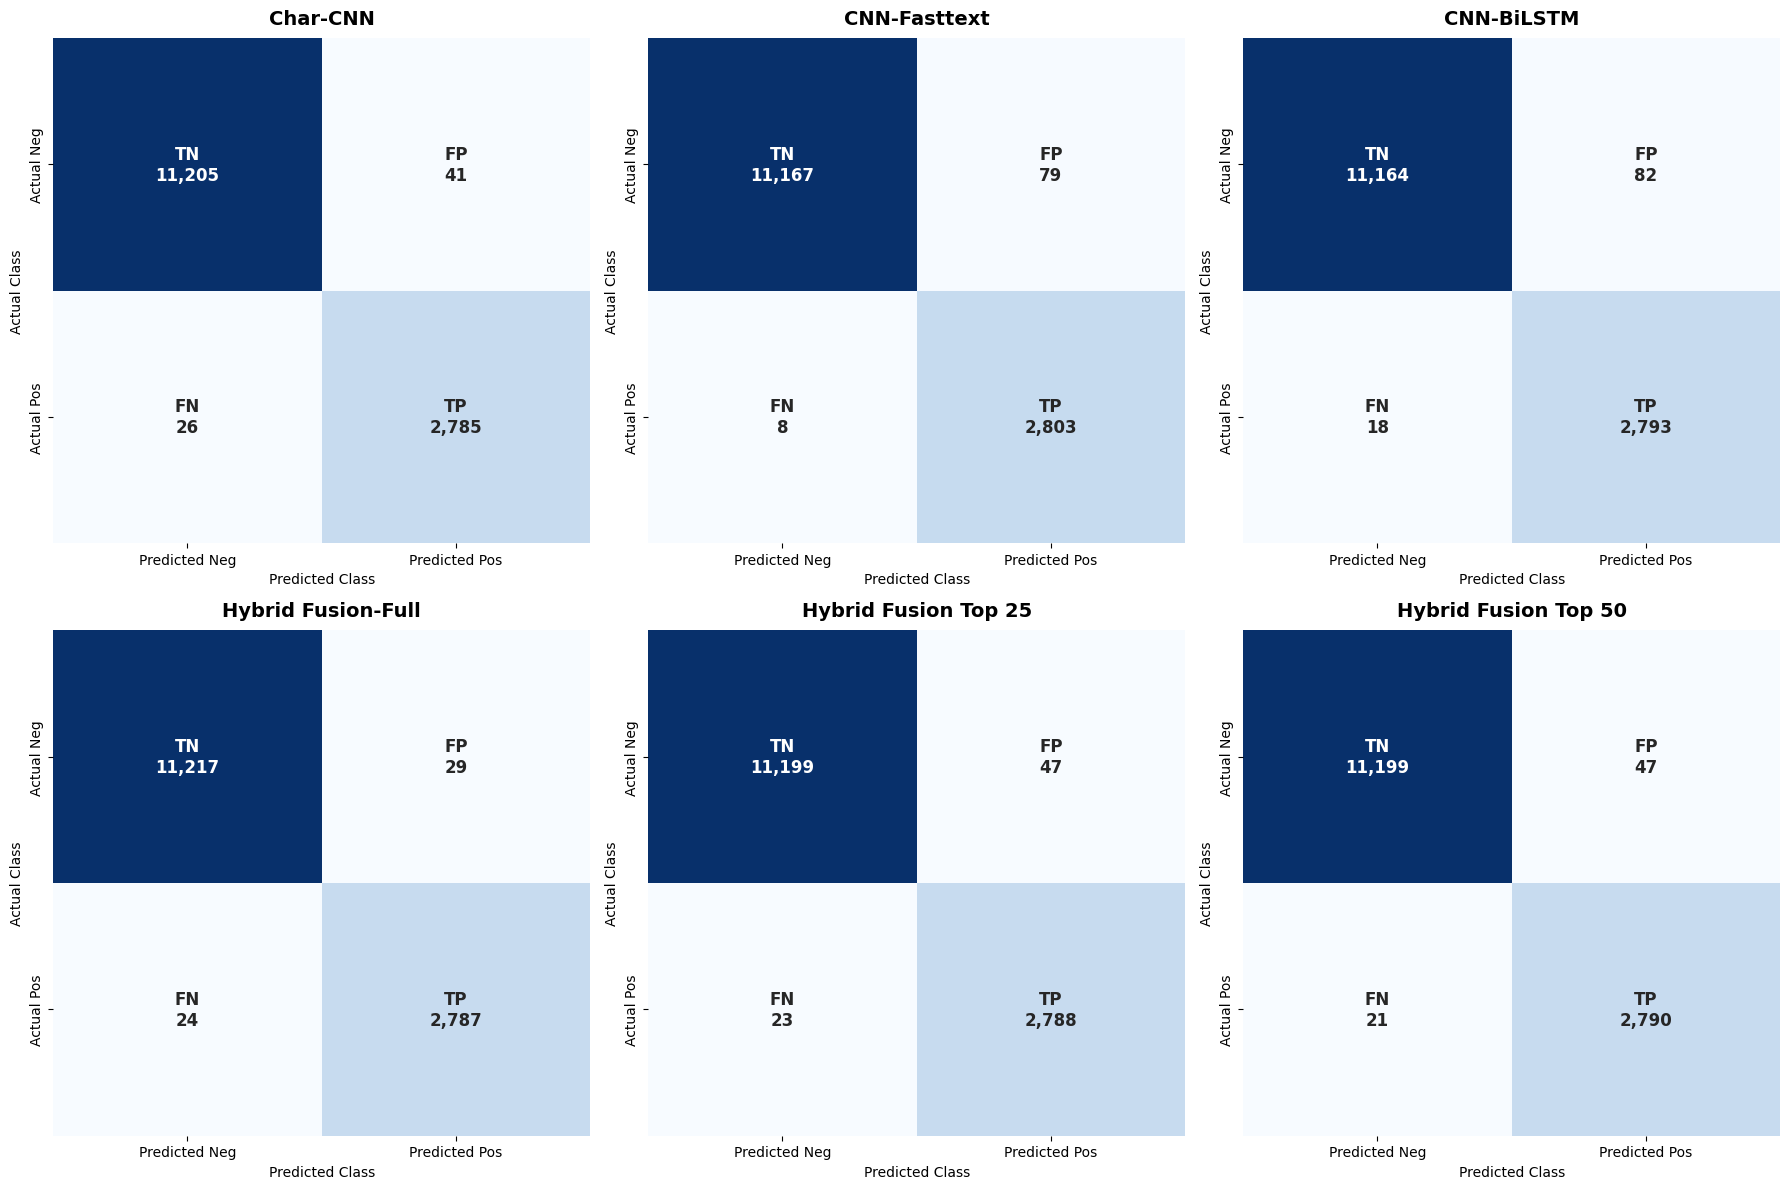

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) # Adjusted for 6 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for idx, row in imb_df.iterrows():
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])


    labels = np.array(
        [
            [f"TN\n{row['TN']:,}", f"FP\n{row['FP']:,}"],
            [f"FN\n{row['FN']:,}", f"TP\n{row['TP']:,}"],
        ]
    )

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
        annot_kws={"size": 12, "weight": "bold"},
        xticklabels=["Predicted Neg", "Predicted Pos"],
        yticklabels=["Actual Neg", "Actual Pos"],
    )

    axes[idx].set_title(row["Model"], fontsize=14, weight="bold", pad=10)
    axes[idx].set_ylabel("Actual Class", fontsize=10)
    axes[idx].set_xlabel("Predicted Class", fontsize=10)
plt.tight_layout()
plt.show()

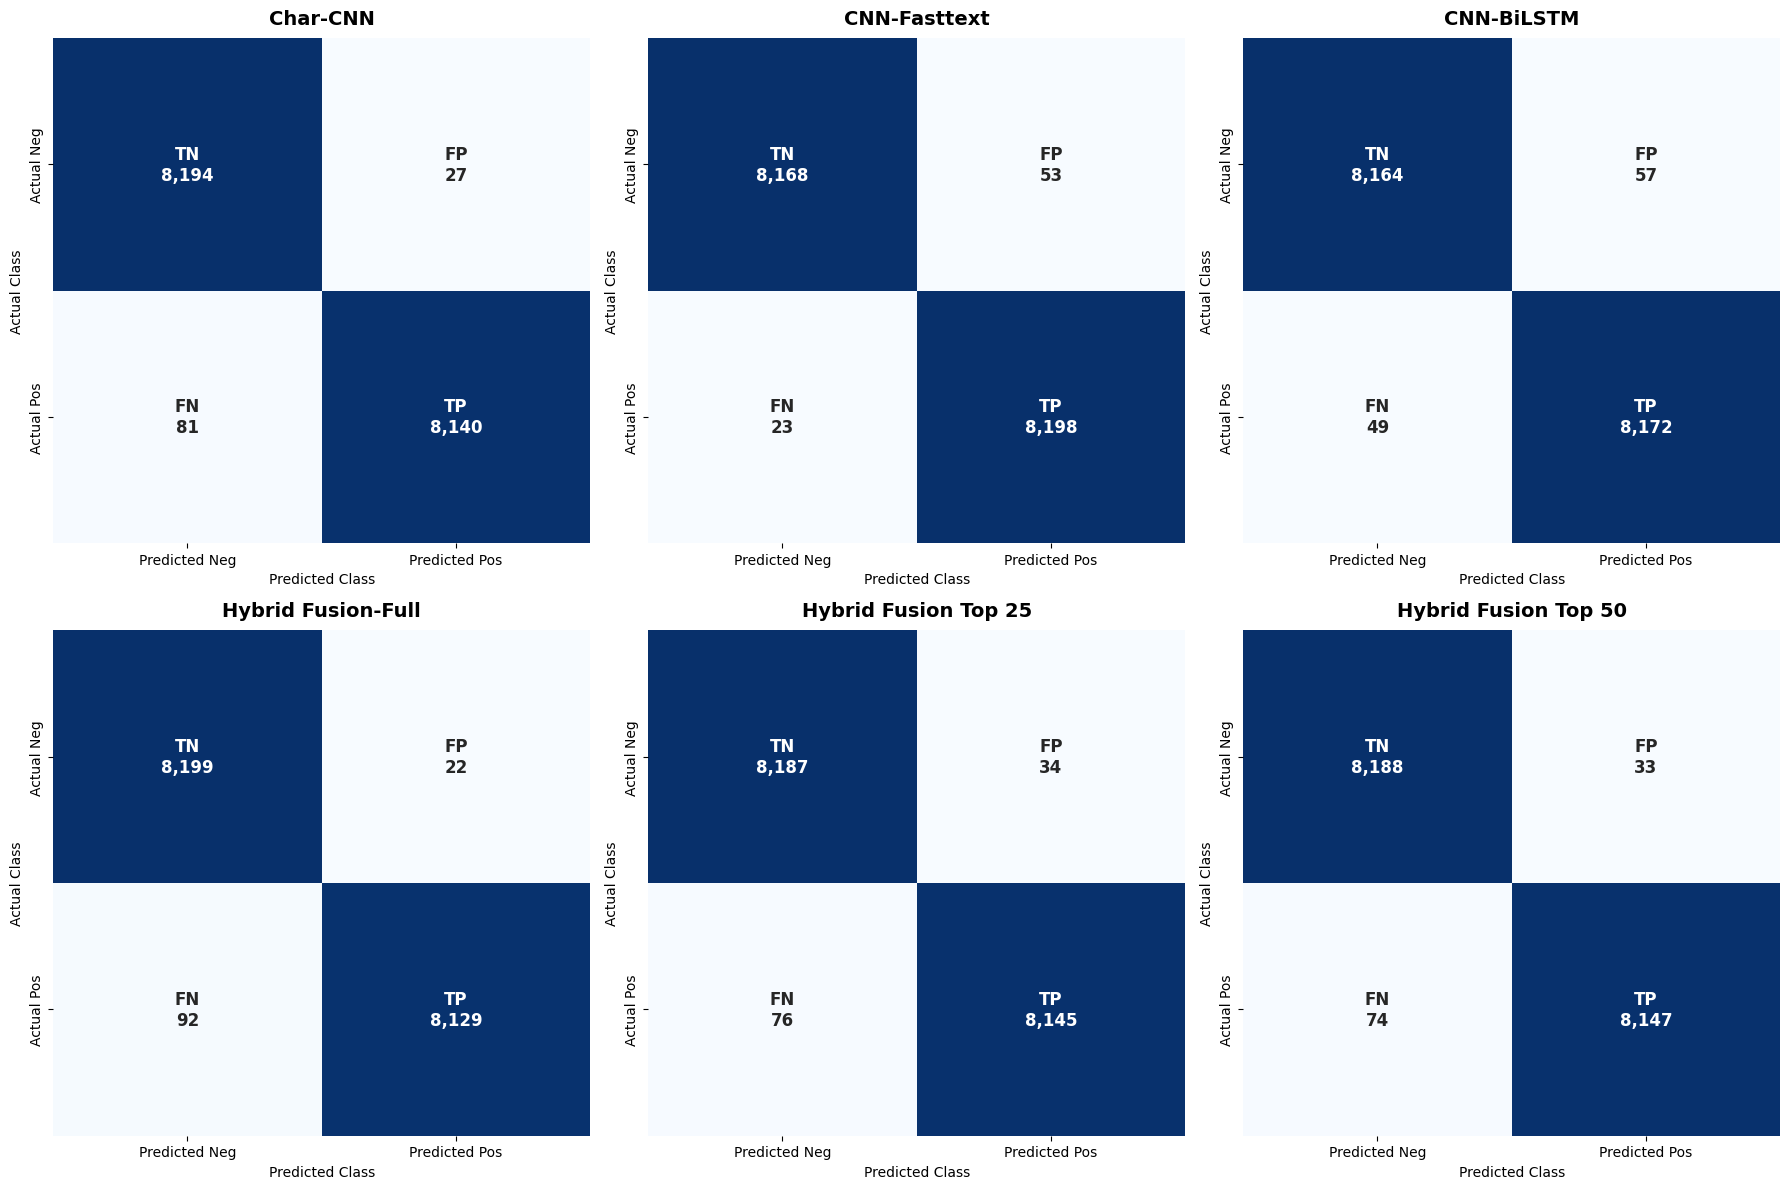

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) # Adjusted for 6 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for idx, row in balance_df.iterrows():
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])


    labels = np.array(
        [
            [f"TN\n{row['TN']:,}", f"FP\n{row['FP']:,}"],
            [f"FN\n{row['FN']:,}", f"TP\n{row['TP']:,}"],
        ]
    )

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
        annot_kws={"size": 12, "weight": "bold"},
        xticklabels=["Predicted Neg", "Predicted Pos"],
        yticklabels=["Actual Neg", "Actual Pos"],
    )

    axes[idx].set_title(row["Model"], fontsize=14, weight="bold", pad=10)
    axes[idx].set_ylabel("Actual Class", fontsize=10)
    axes[idx].set_xlabel("Predicted Class", fontsize=10)
plt.tight_layout()
plt.show()

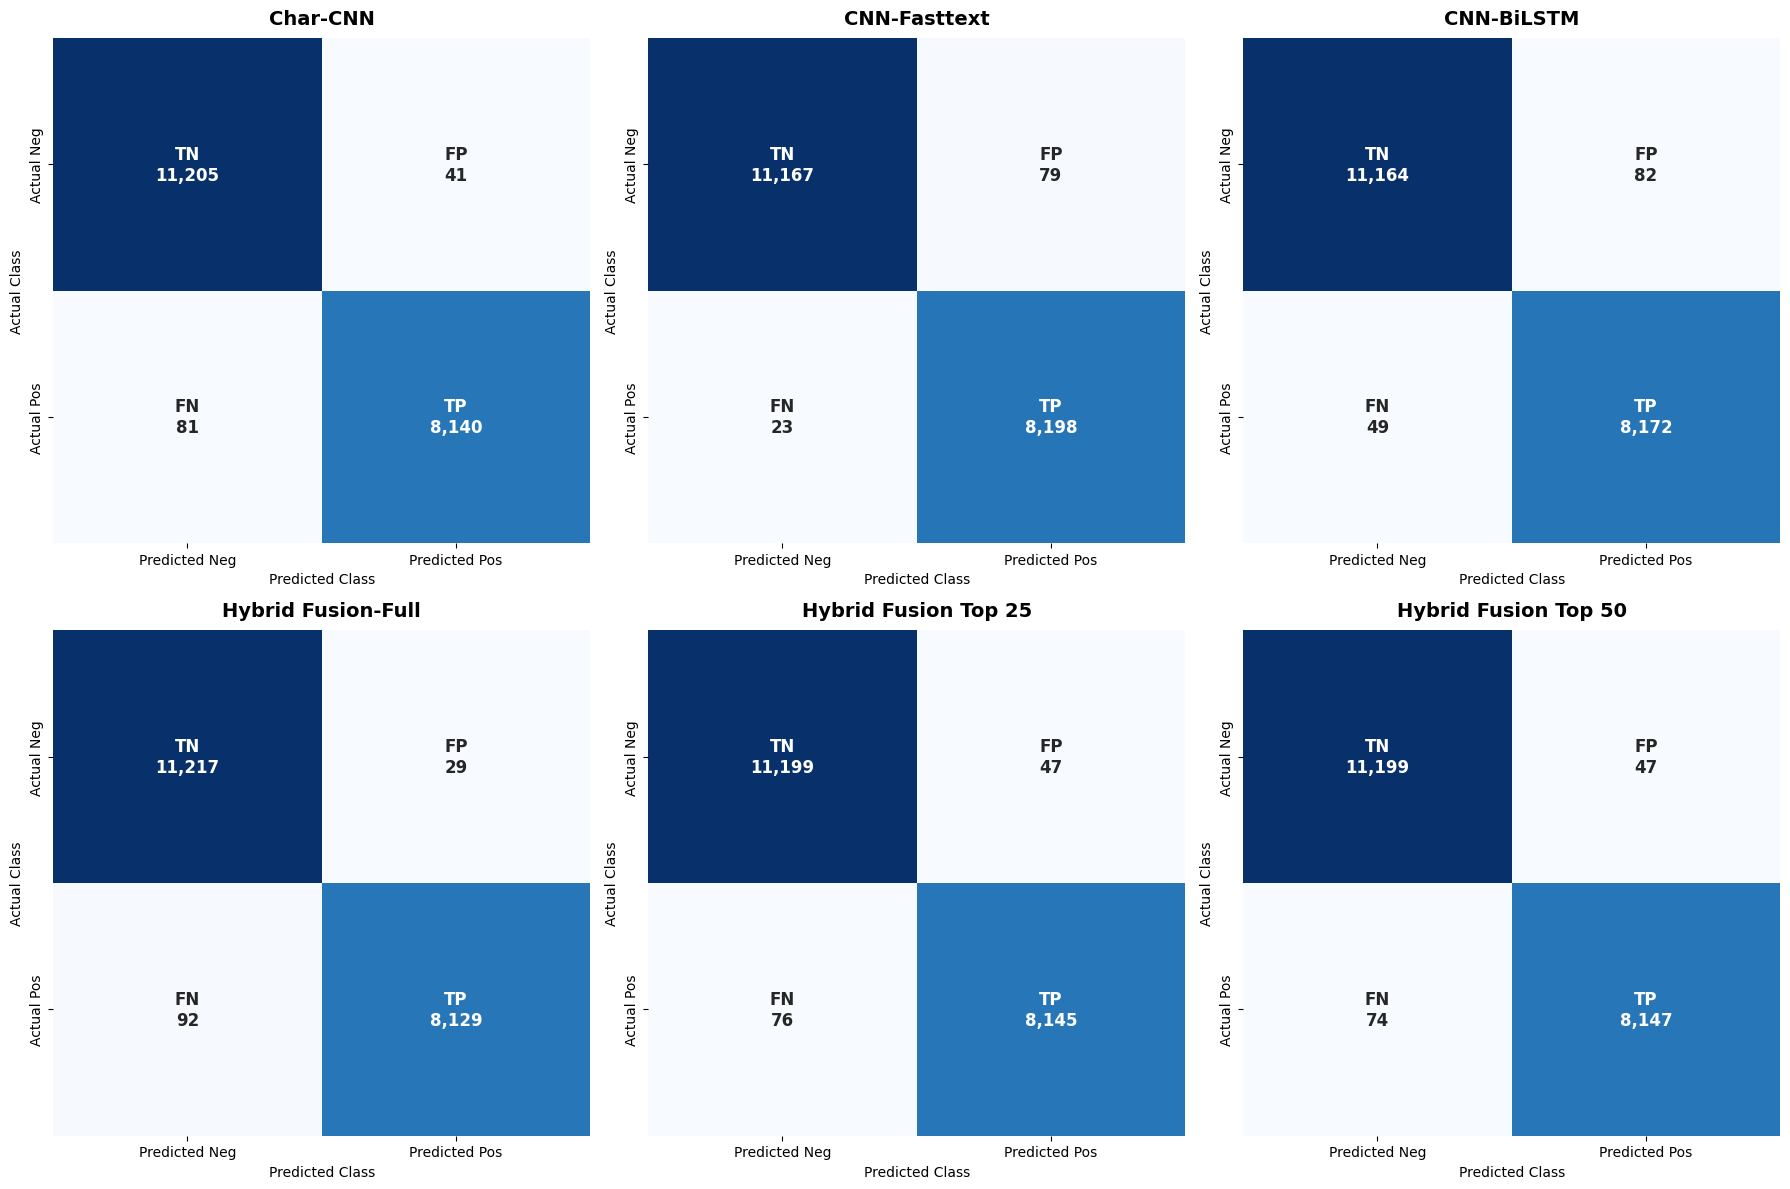

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12)) # Adjusted for 6 plots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for idx, row in orginal_df.iterrows():
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])


    labels = np.array(
        [
            [f"TN\n{row['TN']:,}", f"FP\n{row['FP']:,}"],
            [f"FN\n{row['FN']:,}", f"TP\n{row['TP']:,}"],
        ]
    )

    sns.heatmap(
        cm,
        annot=labels,
        fmt="",
        cmap="Blues",
        cbar=False,
        ax=axes[idx],
        annot_kws={"size": 12, "weight": "bold"},
        xticklabels=["Predicted Neg", "Predicted Pos"],
        yticklabels=["Actual Neg", "Actual Pos"],
    )

    axes[idx].set_title(row["Model"], fontsize=14, weight="bold", pad=10)
    axes[idx].set_ylabel("Actual Class", fontsize=10)
    axes[idx].set_xlabel("Predicted Class", fontsize=10)
plt.tight_layout()
plt.show()